In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import os

## Load dataset

In [2]:
from pathlib import Path

DATA_DIR = Path.cwd().parent.parent / "database" / "gojek" / "cleaned_gojek_data.csv"
print(f"Data directory: {DATA_DIR}")

# Load the dataset
pd.set_option('display.max_columns', None)  # Show all columns
df = pd.read_csv(DATA_DIR)
df

Data directory: /Users/miftahhadiyannoor/Documents/Gojek-Project/database/gojek/cleaned_gojek_data.csv


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,414000.0,23.72,4.3,4.5,Debit Card
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,1.0,Vehicle Breakdown,237000.0,5.73,4.3,4.5,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,627000.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,416000.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,475000.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,333000.0,45.54,4.1,3.7,UPI


In [3]:
df.columns.tolist()

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Booking Value',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method']

In [4]:
# Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.time

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           150000 non-null  float64       
 9   Avg CTAT                           150000 non-null  float64       
 10  Cancelled Rides by C

## 👨‍💻 Goals project

### Build taxi tracking for similar in tracking ride
 * #### Maps tracking - Google maps
### Machine learning to ensure the project is enterprise production for better learnt
* #### Cluster fast way tracks

## Feature Engineering

In [5]:
reason_data = ['Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Driver Ratings',
 'Customer Rating',]

reason_data_df = df[reason_data]
reason_data_df.head()

,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Driver Ratings,Customer Rating
0,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,4.3,4.5
1,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,1.0,Vehicle Breakdown,4.3,4.5
2,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,4.9,4.9
3,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,4.6,5.0
4,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,4.1,4.3


## Define Reason Pools

In [6]:
import random

customer_cancel_reasons = [
    "Changed Mind",
    "Booked by Mistake",
    "Driver Taking Too Long",
    "Found Alternative",
    "Wrong Pickup Location",
    "No Reason Provided"
]

driver_cancel_reasons = [
    "Personal Issue",
    "Vehicle Breakdown",
    "Traffic Issue",
    "Customer Unreachable",
    "Wrong Location",
    "No Reason Provided"
]

incomplete_reasons = [
    "Vehicle Breakdown",
    "Ride Cancelled Midway",
    "Customer Issue",
    "App Error",
    "Route Problem",
    "No Reason Provided"
]

In [7]:
def generate_reason_v2(driver_rating, customer_rating):
    
    # CASE 1: Both good → clean ride
    if driver_rating >= 4.7 and customer_rating >= 4.7:
        return {
            'Cancelled Rides by Customer': "No Cancellation",
            'Reason for cancelling by Customer': "No Cancellation",
            'Cancelled Rides by Driver': "No Cancellation",
            'Driver Cancellation Reason': "No Cancellation",
            'Incomplete Rides': 0.0,
            'Incomplete Rides Reason': "No Cancellation"
        }
    
    # CASE 2: Good driver, bad customer → customer problems
    elif driver_rating >= 4.5 and customer_rating < 4.2:
        return {
            'Cancelled Rides by Customer': "Cancelled, the service is bad",
            'Reason for cancelling by Customer': random.choice(customer_cancel_reasons),
            'Cancelled Rides by Driver': "No Cancellation",
            'Driver Cancellation Reason': "No Cancellation",
            'Incomplete Rides': random.choice([0.0, 1.0]),
            'Incomplete Rides Reason': random.choice(incomplete_reasons)
        }
    
    # CASE 3: Bad driver, good customer → driver problems
    elif driver_rating < 4.2 and customer_rating >= 4.5:
        return {
            'Cancelled Rides by Customer': "No Cancellation",
            'Reason for cancelling by Customer': "No Cancellation",
            'Cancelled Rides by Driver': "Cancelled",
            'Driver Cancellation Reason': random.choice(driver_cancel_reasons),
            'Incomplete Rides': random.choice([1.0, 2.0]),
            'Incomplete Rides Reason': random.choice(incomplete_reasons)
        }
    
    # CASE 4: Both bad → chaos 😄
    elif driver_rating < 4.2 and customer_rating < 4.2:
        return {
            'Cancelled Rides by Customer': "Cancelled, the service is bad",
            'Reason for cancelling by Customer': random.choice(customer_cancel_reasons),
            'Cancelled Rides by Driver': "Cancelled",
            'Driver Cancellation Reason': random.choice(driver_cancel_reasons),
            'Incomplete Rides': random.choice([1.0, 2.0]),
            'Incomplete Rides Reason': random.choice(incomplete_reasons)
        }
    
    # CASE 5: mixed ratings → random reasons
    else:
        return {
            'Cancelled Rides by Customer': random.choice(["No Cancellation", "Cancelled"]),
            'Reason for cancelling by Customer': random.choice(customer_cancel_reasons),
            'Cancelled Rides by Driver': random.choice(["No Cancellation", "Cancelled"]),
            'Driver Cancellation Reason': random.choice(driver_cancel_reasons),
            'Incomplete Rides': random.choice([0.0, 1.0]),
            'Incomplete Rides Reason': random.choice(incomplete_reasons)
        }
    
# Generate new reason columns based on ratings
generated = df.apply(
    lambda row: generate_reason_v2(row['Driver Ratings'], row['Customer Rating']), axis=1
)
generated_df = pd.DataFrame(list(generated))

In [8]:
generated_df

,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason
0,No Cancellation,No Reason Provided,Cancelled,Personal Issue,0.0,Ride Cancelled Midway
1,Cancelled,Booked by Mistake,Cancelled,Wrong Location,1.0,Vehicle Breakdown
2,No Cancellation,No Cancellation,No Cancellation,No Cancellation,0.0,No Cancellation
3,Cancelled,Wrong Pickup Location,Cancelled,Traffic Issue,1.0,No Reason Provided
4,No Cancellation,Booked by Mistake,Cancelled,Customer Unreachable,0.0,App Error
...,...,...,...,...,...,...
149995,"Cancelled, the service is bad",Found Alternative,Cancelled,Personal Issue,2.0,Ride Cancelled Midway
149996,No Cancellation,No Cancellation,No Cancellation,No Cancellation,0.0,No Cancellation
149997,Cancelled,Driver Taking Too Long,Cancelled,Traffic Issue,1.0,App Error
149998,"Cancelled, the service is bad",Wrong Pickup Location,Cancelled,Vehicle Breakdown,2.0,Route Problem


In [9]:
# Merge back to original dataframe
df = df.drop(columns=[
    'Cancelled Rides by Customer',
    'Reason for cancelling by Customer',
    'Cancelled Rides by Driver',
    'Driver Cancellation Reason',
    'Incomplete Rides',
    'Incomplete Rides Reason'
], errors='ignore')

df = pd.concat([df, generated_df], axis=1)
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,414000.0,23.72,4.3,4.5,Debit Card,No Cancellation,No Reason Provided,Cancelled,Personal Issue,0.0,Ride Cancelled Midway
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237000.0,5.73,4.3,4.5,UPI,Cancelled,Booked by Mistake,Cancelled,Wrong Location,1.0,Vehicle Breakdown
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,627000.0,13.58,4.9,4.9,Debit Card,No Cancellation,No Cancellation,No Cancellation,No Cancellation,0.0,No Cancellation
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416000.0,34.02,4.6,5.0,UPI,Cancelled,Wrong Pickup Location,Cancelled,Traffic Issue,1.0,No Reason Provided
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,No Cancellation,Booked by Mistake,Cancelled,Customer Unreachable,0.0,App Error


## Replace data -> Drop location

In [10]:
jakarta_kelurahan = [
    # Jakarta Pusat (44)
    "Gambir", "Kebon Kelapa", "Petojo Utara", "Duri Pulo", "Cideng", "Petojo Selatan",
    "Bendungan Hilir", "Karet Tengsin", "Kebon Melati", "Kebon Kacang", "Kampung Bali",
    "Petamburan", "Gelora", "Menteng", "Pegangsaan", "Cikini", "Kebon Sirih", "Gondangdia",
    "Senen", "Kwitang", "Kenari", "Paseban", "Kramat", "Bungur",
    "Cempaka Putih Timur", "Cempaka Putih Barat", "Rawasari",
    "Galur", "Tanah Tinggi", "Kampung Rawa", "Johar Baru",
    "Gunung Sahari Selatan", "Kemayoran", "Kebon Kosong", "Cempaka Baru",
    "Harapan Mulya", "Sumur Batu", "Serdang", "Utan Panjang",
    "Pasar Baru", "Gunung Sahari Utara", "Mangga Dua Selatan", "Karang Anyar", "Kartini",
 
    # Jakarta Barat (52)
    "Pinangsia", "Glodok", "Keagungan", "Krukut", "Tamansari", "Maphar", "Tangki",
    "Mangga Besar", "Tanah Sareal", "Tambora", "Duri Selatan", "Duri Utara", "Kali Anyar",
    "Pekojan", "Roa Malaka", "Angke", "Jembatan Lima", "Jembatan Besi", "Duri Kepa",
    "Wijaya Kusuma", "Tanjung Duren Utara", "Tanjung Duren Selatan", "Grogol", "Tomang",
    "Jelambar", "Jelambar Baru", "Kedaung Kali Angke", "Cengkareng Barat", "Cengkareng Timur",
    "Kapuk", "Rawa Buaya", "Duri Kosambi", "Kembangan Utara", "Kembangan Selatan",
    "Joglo", "Srengseng", "Meruya Utara", "Meruya Selatan", "Palmerah", "Kemanggisan",
    "Slipi", "Kota Bambu Utara", "Kota Bambu Selatan", "Sukabumi Utara", "Sukabumi Selatan",
    "Kelapa Dua", "Tegal Alur", "Kamal", "Pegadungan", "Kalideres", "Semanan", "Batu Ceper",
 
    # Jakarta Timur (60)
    "Matraman", "Palmeriam", "Kebon Manggis", "Pisangan Baru", "Utan Kayu Utara",
    "Utan Kayu Selatan", "Cipinang Muara", "Cipinang Besar Selatan", "Cipinang Besar Utara",
    "Cipinang Cempedak", "Jatinegara", "Rawa Bunga", "Bali Mester", "Kampung Melayu",
    "Bidara Cina", "Cawang", "Cililitan", "Kramat Jati", "Batu Ampar", "Balekambang",
    "Dukuh", "Tengah", "Gedong", "Cijantung", "Kalisari", "Pekayon",
    "Pasar Rebo", "Susukan", "Ciracas", "Rambutan", "Cibubur",
    "Makasar", "Pinang Ranti", "Cipinang Melayu", "Halim Perdana Kusuma", "Kebon Pala",
    "Penggilingan", "Cakung Barat", "Cakung Timur", "Pulo Gebang", "Ujung Menteng",
    "Rawa Terate", "Pisangan Timur", "Kayu Putih", "Rawamangun", "Jati",
    "Pondok Bambu", "Duren Sawit", "Pondok Kelapa", "Malaka Sari", "Malaka Jaya",
    "Pondok Kopi", "Lubang Buaya", "Cipayung", "Setu", "Bambu Apus",
    "Cilangkap", "Munjul", "Pondok Ranggon", "Kelapa Gading Barat", "Kelapa Gading Timur",
 
    # Jakarta Selatan (58)
    "Tebet Barat", "Tebet Timur", "Kebon Baru", "Bukit Duri", "Manggarai",
    "Manggarai Selatan", "Menteng Dalam", "Menteng Atas", "Pasar Manggis", "Guntur",
    "Setiabudi", "Karet Semanggi", "Karet Kuningan", "Kuningan Timur",
    "Pancoran", "Duren Tiga", "Kalibata", "Pengadegan", "Cikoko",
    "Ciganjur", "Jagakarsa", "Srengseng Sawah", "Tanjung Barat", "Lenteng Agung",
    "Pasar Minggu", "Kebagusan", "Ragunan", "Cilandak Timur", "Jati Padang",
    "Pejaten Timur", "Pejaten Barat", "Kemang", "Bangka", "Pela Mampang",
    "Tegal Parang", "Mampang Prapatan", "Kuningan Barat",
    "Kebayoran Lama Utara", "Kebayoran Lama Selatan", "Grogol Selatan", "Grogol Utara",
    "Pesanggrahan", "Bintaro", "Ulujami", "Cipete Selatan", "Cipete Utara",
    "Petogogan", "Melawai", "Kramat Pela", "Kebayoran Baru",
    "Gandaria Selatan", "Gandaria Utara", "Cipedak", "Cilandak Barat",
    "Lebak Bulus", "Pondok Labu", "Fatmawati", "Pondok Pinang",
 
    # Jakarta Utara (29)
    "Penjaringan", "Pejagalan", "Pluit", "Kamal Muara", "Kapuk Muara", "Tugu Utara",
    "Tugu Selatan", "Semper Barat", "Semper Timur", "Rawa Badak Utara", "Rawa Badak Selatan",
    "Lagoa", "Koja", "Tanjung Priok", "Sunter Agung", "Sunter Jaya", "Papanggo",
    "Sungai Bambu", "Kebon Bawang", "Warakas", "Pademangan Barat", "Pademangan Timur",
    "Ancol", "Kali Baru", "Cilincing", "Sukapura", "Marunda", "Rorotan", "Pulo Gadung",
]

# Remove duplicates while preserving order
jakarta_kelurahan = list(dict.fromkeys(jakarta_kelurahan))
print(f"Total unique kelurahan in Jakarta: {len(jakarta_kelurahan)}")

Total unique kelurahan in Jakarta: 244


In [11]:
# Get all unique original locations
drop_locations = df['Drop Location'].unique().tolist()
pickup_locations = df['Pickup Location'].unique().tolist()

# Create a mapping dict: each original locations -> a Jakarta kelurahan (randomly assigned)
random.seed(42)  # For reproducibility
shuffled_jakarta = jakarta_kelurahan.copy()
random.shuffle(shuffled_jakarta)

# For drop locations
drop_location_map = {}
for i, loc in enumerate(drop_locations):
    drop_location_map[loc] = shuffled_jakarta[i % len(shuffled_jakarta)]

# For pickup locations
shuffled_jakarta_pickup = jakarta_kelurahan.copy()
random.shuffle(shuffled_jakarta_pickup)

pickup_location_map = {}
for i, loc in enumerate(pickup_locations):
    pickup_location_map[loc] = shuffled_jakarta_pickup[i % len(shuffled_jakarta_pickup)]

# Apply mappings
df['Drop Location'] = df['Drop Location'].map(drop_location_map)
df['Pickup Location'] = df['Pickup Location'].map(pickup_location_map)

print("Sample of mapped drop locations:")
print(df['Drop Location'].unique()[:10])

print("\nSample of mapped pickup locations:")
print(df['Pickup Location'].unique()[:10])

Sample of mapped drop locations:
['Glodok' 'Kramat Jati' 'Kebon Kacang' 'Kota Bambu Utara'
 'Cipinang Cempedak' 'Bintaro' 'Pondok Labu' 'Penggilingan' 'Pela Mampang'
 'Pinangsia']

Sample of mapped pickup locations:
['Tanah Tinggi' 'Cipinang Melayu' 'Mangga Dua Selatan' 'Glodok'
 'Sunter Jaya' 'Semanan' 'Pesanggrahan' 'Rambutan' 'Sunter Agung'
 'Pondok Ranggon']


In [12]:
df['Drop Location'].to_dict()

{0: 'Glodok',
 1: 'Kramat Jati',
 2: 'Kebon Kacang',
 3: 'Kota Bambu Utara',
 4: 'Cipinang Cempedak',
 5: 'Bintaro',
 6: 'Pondok Labu',
 7: 'Penggilingan',
 8: 'Pela Mampang',
 9: 'Pinangsia',
 10: 'Cibubur',
 11: 'Grogol Utara',
 12: 'Kampung Rawa',
 13: 'Joglo',
 14: 'Balekambang',
 15: 'Cipinang Cempedak',
 16: 'Rawamangun',
 17: 'Balekambang',
 18: 'Paseban',
 19: 'Susukan',
 20: 'Mampang Prapatan',
 21: 'Cipedak',
 22: 'Kelapa Gading Barat',
 23: 'Jagakarsa',
 24: 'Paseban',
 25: 'Grogol',
 26: 'Pasar Rebo',
 27: 'Cipayung',
 28: 'Cipedak',
 29: 'Kebon Kacang',
 30: 'Rawa Badak Selatan',
 31: 'Slipi',
 32: 'Tegal Parang',
 33: 'Melawai',
 34: 'Joglo',
 35: 'Kebon Kacang',
 36: 'Cijantung',
 37: 'Pulo Gadung',
 38: 'Jembatan Besi',
 39: 'Kapuk',
 40: 'Ancol',
 41: 'Gelora',
 42: 'Menteng Atas',
 43: 'Menteng Atas',
 44: 'Utan Kayu Utara',
 45: 'Galur',
 46: 'Galur',
 47: 'Tegal Parang',
 48: 'Tegal Parang',
 49: 'Gelora',
 50: 'Pondok Pinang',
 51: 'Kampung Melayu',
 52: 'Pisangan 

In [13]:
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
df['hour'] = df['Datetime'].dt.hour
df['day_of_week'] = df['Datetime'].dt.dayofweek

In [14]:
# Encode locations
from sklearn.preprocessing import LabelEncoder

le_pickup = LabelEncoder()
le_drop = LabelEncoder()

df['Pickup Encoded'] = le_pickup.fit_transform(df['Pickup Location'])
df['Drop Encoded'] = le_drop.fit_transform(df['Drop Location'])

## 🚀 Cluster fast route patterns

In [15]:
# Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df['route_cluster'] = kmeans.fit_predict(df[['Pickup Encoded', 'Drop Encoded', 'hour']])

In [16]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Datetime,hour,day_of_week,Pickup Encoded,Drop Encoded,route_cluster
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Tanah Tinggi,Glodok,8.3,28.8,414000.0,23.72,4.3,4.5,Debit Card,No Cancellation,No Reason Provided,Cancelled,Personal Issue,0.0,Ride Cancelled Midway,2024-03-23 12:29:38,12,5,160,40,2
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Cipinang Melayu,Kramat Jati,4.9,14.0,237000.0,5.73,4.3,4.5,UPI,Cancelled,Booked by Mistake,Cancelled,Wrong Location,1.0,Vehicle Breakdown,2024-11-29 18:01:39,18,4,24,86,0
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Mangga Dua Selatan,Kebon Kacang,13.4,25.8,627000.0,13.58,4.9,4.9,Debit Card,No Cancellation,No Cancellation,No Cancellation,No Cancellation,0.0,No Cancellation,2024-08-23 08:56:10,8,4,96,73,4
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Glodok,Kota Bambu Utara,13.1,28.5,416000.0,34.02,4.6,5.0,UPI,Cancelled,Wrong Pickup Location,Cancelled,Traffic Issue,1.0,No Reason Provided,2024-10-21 17:17:25,17,0,31,85,0
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Sunter Jaya,Cipinang Cempedak,5.3,19.6,737.0,48.21,4.1,4.3,UPI,No Cancellation,Booked by Mistake,Cancelled,Customer Unreachable,0.0,App Error,2024-09-16 22:08:00,22,0,157,28,2


## 🧠 Feature Engineering 

In [17]:
# 1a. Distance-based features
df['distance_per_hour'] = df['Ride Distance'] / (df['hour'] + 1)
df['log_distance'] = np.log1p(df['Ride Distance'])
df['distance_squared'] = df['Ride Distance'] ** 2
df['distance_sqrt'] = np.sqrt(df['Ride Distance'])

# 1b. Time-based features
df['is_peak_hour'] = df['hour'].apply(lambda h: 1 if h in [7,8,9,17,18,19,20] else 0)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = df['hour'].apply(lambda h: 1 if h >= 22 or h <= 5 else 0)

# Cyclical encoding for hour and day of week
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Traffic score
def traffic_score(hour, is_weekend):
    if is_weekend:
        return 1 if hour < 10 else 2
    if 7 <= hour <= 9 or 17 <= hour <= 20:
        return 3
    elif 10 <= hour <= 16:
        return 2
    else:
        return 1
df['traffic_score'] = df.apply(lambda x: traffic_score(x['hour'], x['is_weekend']), axis=1)

# 1d. Safe route aggregations
df = df.sort_values('Datetime')

df['route_avg_ctat_safe'] = (df.groupby(['Pickup Encoded', 'Drop Encoded'])['Avg CTAT'].transform
                        (lambda x: x.shift().rolling(window=20, min_periods=1).mean()))
df['route_avg_price_safe'] = (df.groupby(['Pickup Encoded', 'Drop Encoded'])['Booking Value'].transform(
    lambda x: x.shift(1).rolling(window=20, min_periods=1).mean()
))

# 1c. Rating-based features
df['rating_diff'] = df['Driver Ratings'] - df['Customer Rating']
df['rating_product'] = df['Driver Ratings'] * df['Customer Rating']
df['avg_rating'] = (df['Driver Ratings'] + df['Customer Rating']) / 2
df['low_driver_rating'] = (df['Driver Ratings'] < 4.2).astype(int)
df['low_customer_rating'] = (df['Customer Rating'] < 4.2).astype(int)

# Behavior scores
df['driver_score'] = df['Driver Ratings'] * (1 - df['Cancelled Rides by Driver'].apply(lambda x: 1 if x == "Cancelled" else 0))

# Demand features
df['hourly_demand'] = df.groupby('hour')['Booking ID'].transform('count')
df['route_demand'] = df.groupby(['Pickup Encoded', 'Drop Encoded'])['Booking ID'].transform('count')
df['demand_pressure'] = df['hourly_demand'] / (df['route_demand'] + 1)
df['route_count'] = df.groupby(['Pickup Encoded', 'Drop Encoded'])['Booking ID'].transform('count')

# Handle skewed features with log transformation
df['log_price'] = np.log1p(df['Booking Value'])
df['log_ctat'] = np.log1p(df['Avg CTAT'])
df['log_route_count'] = np.log1p(df['route_count'])

df['log_route_price'] = np.log1p(df['route_avg_price_safe'])
df['log_route_ctat'] = np.log1p(df['route_avg_ctat_safe'])

# Handle missing values in log features by fillna
df['log_route_ctat'] = df['log_route_ctat'].fillna(df['log_route_ctat'].median())
df['log_route_price'] = df['log_route_price'].fillna(df['log_route_price'].median())


# 1e. Interaction features
df['time_distance_interaction'] = df['Ride Distance'] * df['traffic_score']
df['route_complexity'] = df['route_count'] * df['traffic_score']
df['peak_pressure'] = df['is_peak_hour'] * df['route_count']

# Remove outliers with z-score
from scipy import stats

# IQR method
def clip_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)
    return df

# Apply clipping
cols_to_clip = [
    'Ride Distance',
    'distance_per_hour',
    'rating_diff',
    'rating_product',
    'avg_rating',
    'route_avg_ctat_safe',
    'route_avg_price_safe',
    'route_avg_distance',
    'route_count'
]

for col in cols_to_clip:
    if col in df.columns:
        df = clip_outliers(df, col)
        print(f"Clipped outliers in {col} using IQR method.")
        print(f"New min: {df[col].min()}, New max: {df[col].max()}")

# List of columns to drop (if they exist)
drop_cols = [
    'rating_product',          # too noisy
    'route_avg_price_safe',    # replaced with log
    'route_avg_ctat_safe'      # replaced with log
#    'Pickup Encoded',
#    'Drop Encoded',
#    'route_cluster',
    'route_avg_ctat',
    'route_avg_price'
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

Clipped outliers in Ride Distance using IQR method.
New min: 1.0, New max: 50.0
Clipped outliers in distance_per_hour using IQR method.
New min: 0.045454545454545456, New max: 4.3127272727272725
Clipped outliers in rating_diff using IQR method.
New min: -0.7500000000000007, New max: 0.4500000000000004
Clipped outliers in rating_product using IQR method.
New min: 16.125, New max: 21.284999999999997
Clipped outliers in avg_rating using IQR method.
New min: 4.0249999999999995, New max: 4.625000000000001
Clipped outliers in route_avg_ctat_safe using IQR method.
New min: 17.96666666666667, New max: 40.099999999999994
Clipped outliers in route_avg_price_safe using IQR method.
New min: 736.0, New max: 678750.0
Clipped outliers in route_count using IQR method.
New min: 1.0, New max: 11.5


In [18]:
df.columns.tolist()

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Booking Value',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Datetime',
 'hour',
 'day_of_week',
 'Pickup Encoded',
 'Drop Encoded',
 'route_cluster',
 'distance_per_hour',
 'log_distance',
 'distance_squared',
 'distance_sqrt',
 'is_peak_hour',
 'is_weekend',
 'is_night',
 'hour_sin',
 'hour_cos',
 'day_sin',
 'day_cos',
 'traffic_score',
 'route_avg_ctat_safe',
 'rating_diff',
 'avg_rating',
 'low_driver_rating',
 'low_customer_rating',
 'driver_score',
 'hourly_demand',
 'route_demand',
 'demand_pressure',
 'route_count',
 'log_price',
 'log_ctat',
 'log_route_count',
 'log_route_price',
 'log_route_ctat',
 'time_distance_int

In [19]:
df.describe()

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Incomplete Rides,hour,day_of_week,Pickup Encoded,Drop Encoded,route_cluster,distance_per_hour,log_distance,distance_squared,distance_sqrt,is_peak_hour,is_weekend,is_night,hour_sin,hour_cos,day_sin,day_cos,traffic_score,route_avg_ctat_safe,rating_diff,avg_rating,low_driver_rating,low_customer_rating,driver_score,hourly_demand,route_demand,demand_pressure,route_count,log_price,log_ctat,log_route_count,log_route_price,log_route_ctat,time_distance_interaction,route_complexity,peak_pressure
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,119436.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,8.445407,29.037753,316445.377680,24.343568,4.257215,4.440842,0.627987,14.034113,2.996987,87.438033,87.489433,2.013587,1.828165,3.092464,726.111691,4.766112,0.431087,0.286267,0.118433,-0.242204,-0.212834,-0.001401,0.002480,2.099840,29.026393,-0.181252,4.360148,0.199880,0.129893,2.025076,8151.77440,5.876627,1332.045775,5.864570,11.847692,3.370253,1.873070,12.453217,3.388868,51.051767,12.341933,2.533393
std,3.639311,7.343053,189319.257504,11.554362,0.345619,0.347835,0.614716,5.416906,2.003202,50.866407,50.873651,1.374026,1.118231,0.592792,616.816850,1.275835,0.495230,0.452017,0.323122,0.714842,0.620520,0.707132,0.707080,0.710949,4.810001,0.335588,0.173325,0.399911,0.336187,2.189809,2779.55253,2.217271,709.070560,2.180669,2.125865,0.260694,0.341374,1.101101,0.159265,30.807240,6.451094,3.253416
min,2.000000,10.000000,736.000000,1.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.045455,0.693147,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-0.974928,-0.900969,1.000000,17.966667,-0.750000,4.025000,0.000000,0.000000,0.000000,1321.00000,1.000000,83.687500,1.000000,6.602588,2.397895,0.693147,6.602588,2.397895,1.000000,1.000000,0.000000
25%,5.600000,25.000000,160000.000000,17.360000,4.200000,4.300000,0.000000,10.000000,1.000000,43.000000,43.000000,1.000000,1.078182,2.910174,301.369600,4.166533,0.000000,0.000000,0.000000,-0.866025,-0.707107,-0.781831,-0.900969,2.000000,26.266667,-0.300000,4.250000,0.000000,0.000000,0.000000,6861.00000,4.000000,878.875000,4.000000,11.982935,3.258097,1.609438,12.487690,3.340208,24.420000,8.000000,0.000000
50%,8.300000,28.800000,414000.000000,23.720000,4.300000,4.500000,1.000000,15.000000,3.000000,88.000000,87.000000,2.000000,1.571348,3.207613,562.638400,4.870318,0.000000,0.000000,0.000000,-0.500000,-0.258819,0.000000,-0.222521,2.000000,28.800000,-0.200000,4.400000,0.000000,0.000000,0.000000,8234.00000,6.000000,1203.750000,6.000000,12.933624,3.394508,1.945910,12.700787,3.394508,47.440000,12.000000,0.000000
75%,11.000000,32.900000,414000.000000,30.650000,4.300000,4.600000,1.000000,18.000000,5.000000,131.000000,132.000000,3.000000,2.372000,3.454738,939.422500,5.536244,1.000000,1.000000,0.000000,0.500000,0.258819,0.781831,0.623490,3.000000,31.800000,0.000000,4.400000,0.000000,0.000000,4.300000,9633.00000,7.000000,1640.400000,7.000000,12.933624,3.523415,2.079442,12.893806,3.458418,71.160000,16.000000,5.000000
max,20.000000,45.000000,735000.000000,50.000000,5.000000,5.000000,2.000000,23.000000,6.000000,175.000000,175.000000,4.000000,4.312727,3.931826,2500.000000,7.071068,1.000000,1.000000,1.000000,1.000000,1.000000,0.974928,1.000000,3.000000,40.100000,0.450000,4.625000,1.000000,1.000000,5.000000,12397.00000,17.000000,6198.500000,11.500000,13.507627,3.828641,2.890372,13.507627,3.828641,150.000000,51.000000,17.000000


In [20]:
features = [
    # Original features
    'Pickup Encoded',
    'Drop Encoded',
    'Ride Distance',
    'hour',
    'day_of_week',
    'Driver Ratings',
    'Customer Rating',
    'route_cluster',

    # New engineered features
    'log_distance',
    'distance_per_hour',
    'is_peak_hour',
    'is_weekend',
    'is_night',
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos',
    'rating_diff',
    'rating_product',
    'avg_rating',
    'low_driver_rating',
    'low_customer_rating',
    'route_avg_ctat',
    'route_avg_price',
    'route_avg_distance',
    'route_count',
]

features_new = [
 # Distance
    'Ride Distance',
    'log_distance',
    'distance_per_hour',

    # Time
    'hour_sin',
    'hour_cos',
    'is_peak_hour',
    'is_weekend',
    'traffic_score',

    # Ratings
    'Driver Ratings',
    'Customer Rating',
    'rating_diff',
    'avg_rating',
    'driver_score',

    # Demand
#    'hourly_demand',
    'route_demand',
    'demand_pressure',

    # Route (LOG version)
#    'log_route_ctat',
#    'log_route_price',
    'log_route_count',

    # Interaction
    'time_distance_interaction',
    'route_complexity',
    'peak_pressure'
]

X = df[features_new]

In [21]:
X

,Ride Distance,log_distance,distance_per_hour,hour_sin,hour_cos,is_peak_hour,is_weekend,traffic_score,Driver Ratings,Customer Rating,rating_diff,avg_rating,driver_score,route_demand,demand_pressure,log_route_count,time_distance_interaction,route_complexity,peak_pressure
122017,37.98,3.663049,4.312727,0.000000,1.000000,0,0,1,4.8,4.8,0.00,4.625,4.8,5,228.833333,1.791759,37.98,5,0
79457,39.29,3.696103,4.312727,0.258819,0.965926,0,0,1,4.2,4.1,0.10,4.150,0.0,2,453.333333,1.098612,39.29,2,0
19130,23.72,3.207613,4.312727,0.258819,0.965926,0,0,1,4.3,4.5,-0.20,4.400,4.3,4,272.000000,1.609438,23.72,4,0
47361,23.72,3.207613,4.312727,0.258819,0.965926,0,0,1,4.3,4.5,-0.20,4.400,0.0,7,170.000000,2.079442,23.72,7,0
33452,23.72,3.207613,4.312727,0.258819,0.965926,0,0,1,4.3,4.5,-0.20,4.400,0.0,7,170.000000,2.079442,23.72,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37673,12.85,2.628285,0.558696,-0.500000,0.866025,0,0,1,4.4,4.8,-0.40,4.600,0.0,6,777.285714,1.945910,12.85,6,0
61365,39.36,3.697839,1.640000,-0.258819,0.965926,0,0,1,3.8,4.3,-0.50,4.050,0.0,4,552.400000,1.609438,39.36,4,0
2518,38.91,3.686627,1.621250,-0.258819,0.965926,0,0,1,4.3,4.6,-0.30,4.450,4.3,5,460.333333,1.791759,38.91,5,0
88884,36.37,3.620868,1.515417,-0.258819,0.965926,0,0,1,5.0,4.3,0.45,4.625,5.0,4,552.400000,1.609438,36.37,4,0


In [22]:
# Analyze cluster characteristics
df.groupby('route_count')[[
    'Ride Distance',
    'Avg CTAT',
    'Avg VTAT',
    'Booking Value'
]].mean()

,Ride Distance,Avg CTAT,Avg VTAT,Booking Value
route_count,,,,
1.0,24.227806,28.996144,8.221937,313862.005141
2.0,24.501560,28.991610,8.534995,321666.777340
3.0,24.254607,29.013417,8.483392,317589.876027
4.0,24.309392,29.086783,8.416442,317028.443345
5.0,24.325554,29.075987,8.458018,315848.774454
6.0,24.374051,29.076340,8.460658,316602.519201
7.0,24.313293,29.005075,8.401546,315495.465234
8.0,24.510927,29.019030,8.459468,317296.406317
9.0,24.371280,29.006658,8.408131,316625.122245


## Check data outliers

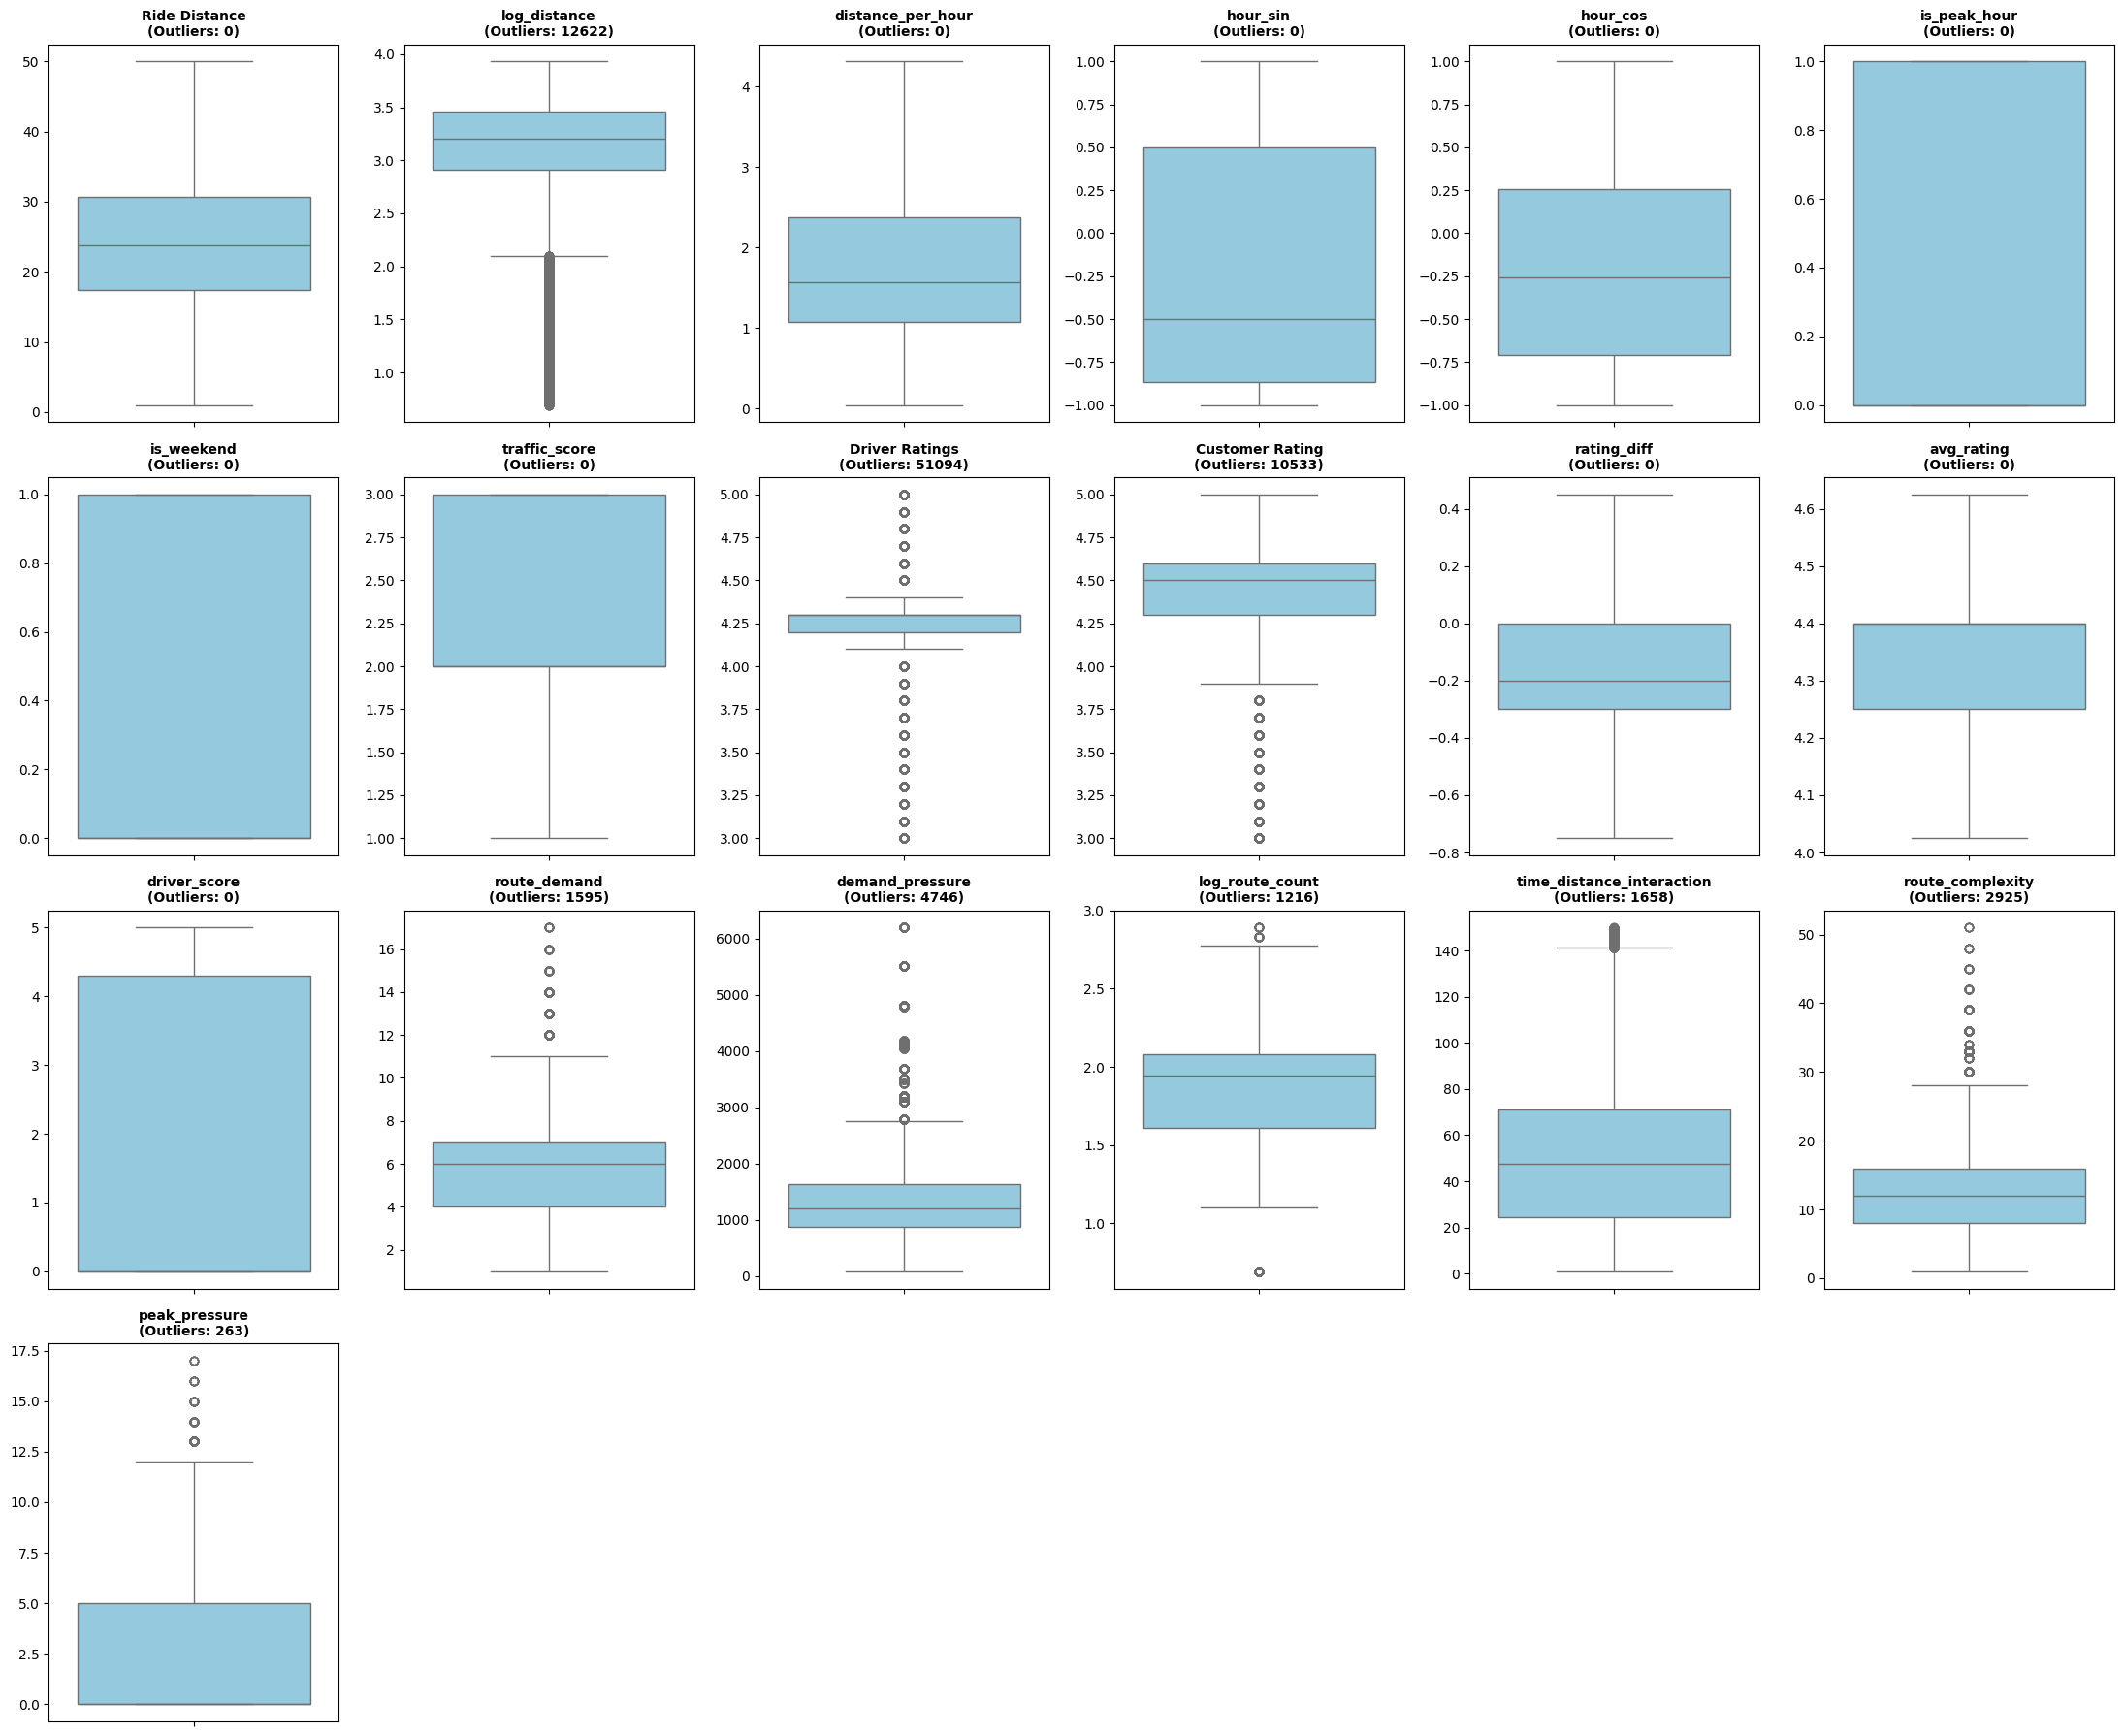

Total features: 19
Grid size: 4 × 6


In [23]:
# Boxplots with outlier detection
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def count_outliers(data, column):
    """Count outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data[column] < (Q1 - 1.5 * IQR)) | (data[column] > (Q3 + 1.5 * IQR))).sum()
    return outliers

n_features = len(features_new)
n_cols = 6
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.5*n_rows))
axes = axes.flatten()

for idx, feature in enumerate(features_new):
    sns.boxplot(data=df, y=feature, ax=axes[idx], color='skyblue')
    
    # Count and display outliers
    outlier_count = count_outliers(df, feature)
    axes[idx].set_title(
        f"{feature}\n(Outliers: {outlier_count})", 
        fontsize=10, 
        fontweight='bold'
    )
    axes[idx].set_ylabel("")

for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Total features: {n_features}")
print(f"Grid size: {n_rows} × {n_cols}")

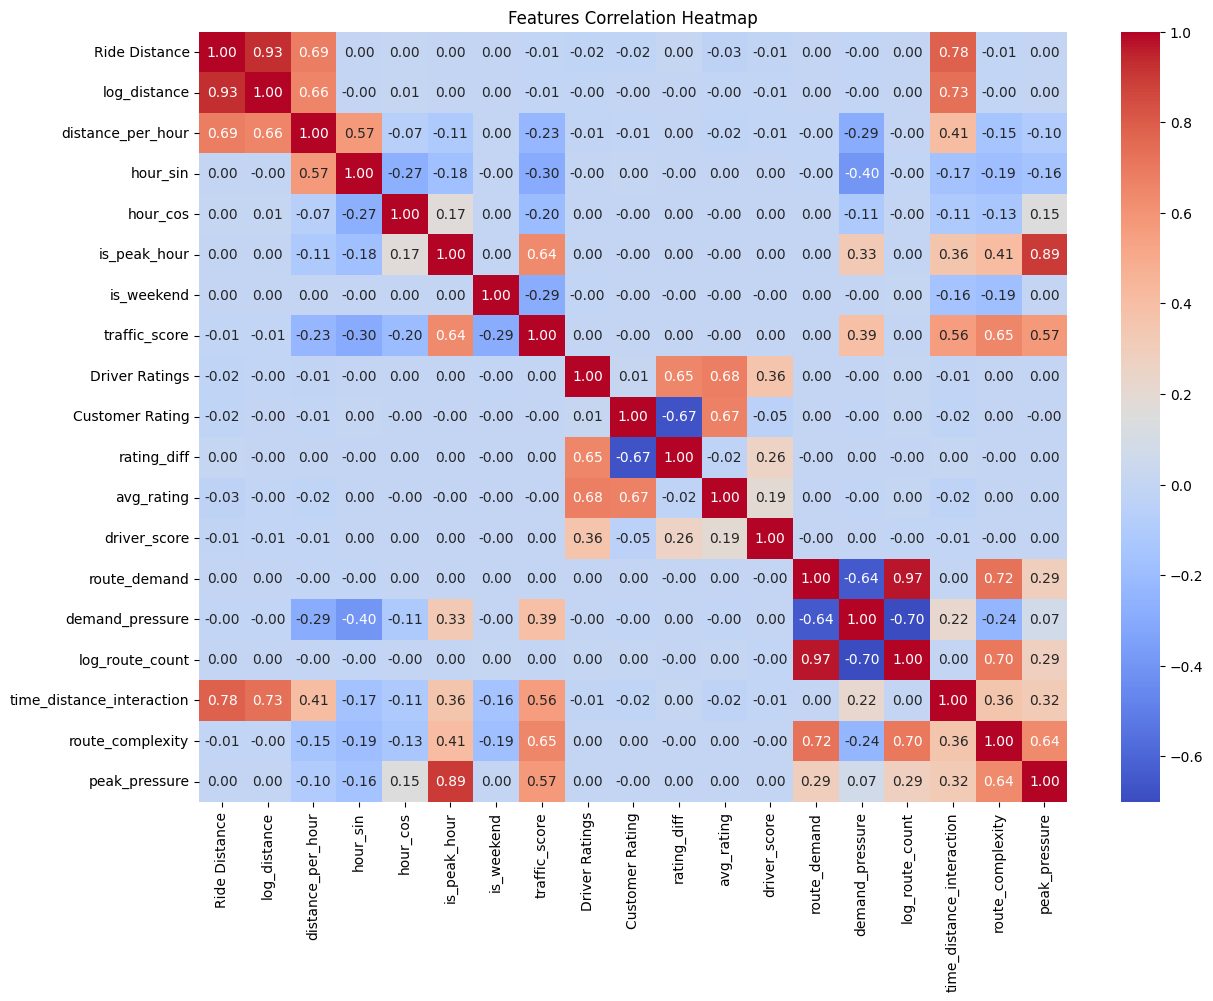

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap of feature correlations
corr = X.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Features Correlation Heatmap")
plt.show()

## Scale data

In [25]:
missing_cols = [col for col in features_new if col not in df.columns]
print(f"Missing columns in the dataset: {missing_cols}")

Missing columns in the dataset: []


In [26]:
from sklearn.preprocessing import StandardScaler

df_cleaned_iqr = df.copy()

# Define X and y
X_clean = df_cleaned_iqr[features_new].copy()
X_clean = X_clean.fillna(0)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean) 
X_scaled_df = pd.DataFrame(X_scaled, columns=features_new)
print(f"X_Scaled shape: {X_scaled.shape}")

X_Scaled shape: (150000, 19)


## Data quality check & analysis

In [27]:
# ============================================================
# DATA QUALITY & TARGET ANALYSIS
# ============================================================
print("="*70)
print("DATA QUALITY ANALYSIS")
print("="*70)

# Check target distributions
print("\n📊 TARGET VARIABLES DISTRIBUTION:")
print(f"\nAvg CTAT (Customer Time to Arrival):")
print(f"  Min: {df_cleaned_iqr['Avg CTAT'].min():.4f}, Max: {df_cleaned_iqr['Avg CTAT'].max():.4f}")
print(f"  Mean: {df_cleaned_iqr['Avg CTAT'].mean():.4f}, Std: {df_cleaned_iqr['Avg CTAT'].std():.4f}")
print(f"  Median: {df_cleaned_iqr['Avg CTAT'].median():.4f}")
print(f"  Skewness: {df_cleaned_iqr['Avg CTAT'].skew():.4f}")

print(f"\nAvg VTAT (Vehicle Time to Arrival):")
print(f"  Min: {df_cleaned_iqr['Avg VTAT'].min():.4f}, Max: {df_cleaned_iqr['Avg VTAT'].max():.4f}")
print(f"  Mean: {df_cleaned_iqr['Avg VTAT'].mean():.4f}, Std: {df_cleaned_iqr['Avg VTAT'].std():.4f}")
print(f"  Median: {df_cleaned_iqr['Avg VTAT'].median():.4f}")
print(f"  Skewness: {df_cleaned_iqr['Avg VTAT'].skew():.4f}")

# Check for missing values
print(f"\n🔍 MISSING VALUES:")
missing_in_features = X_clean.isnull().sum().sum()
print(f"  Total missing in features: {missing_in_features}")
print(f"  Missing in CTAT: {df_cleaned_iqr['Avg CTAT'].isnull().sum()}")
print(f"  Missing in VTAT: {df_cleaned_iqr['Avg VTAT'].isnull().sum()}")

# Check feature variance
print(f"\n📈 FEATURE VARIANCE ANALYSIS:")
feature_variance = X_clean.var().sort_values(ascending=False)
print(f"  Top 5 highest variance features:")
for feat, var in feature_variance.head(5).items():
    print(f"    {feat}: {var:.4f}")

print(f"\n  Features with zero/very low variance (< 0.01):")
low_var_features = feature_variance[feature_variance < 0.01]
for feat, var in low_var_features.items():
    print(f"    {feat}: {var:.6f}")

# Check correlations with targets
print(f"\n🔗 FEATURE-TARGET CORRELATIONS:")
all_features_with_targets = pd.concat([X_clean, df_cleaned_iqr[['Avg CTAT', 'Avg VTAT']]], axis=1)
correlations_ctat = all_features_with_targets.corr()['Avg CTAT'].sort_values(ascending=False)
correlations_vtat = all_features_with_targets.corr()['Avg VTAT'].sort_values(ascending=False)

print(f"\n  Top 5 correlated with Avg CTAT:")
for feat, corr in correlations_ctat.head(6).items():
    if feat != 'Avg CTAT':
        print(f"    {feat}: {corr:.4f}")

print(f"\n  Top 5 correlated with Avg VTAT:")
for feat, corr in correlations_vtat.head(6).items():
    if feat != 'Avg VTAT':
        print(f"    {feat}: {corr:.4f}")

print("\n" + "="*70)

DATA QUALITY ANALYSIS

📊 TARGET VARIABLES DISTRIBUTION:

Avg CTAT (Customer Time to Arrival):
  Min: 10.0000, Max: 45.0000
  Mean: 29.0378, Std: 7.3431
  Median: 28.8000
  Skewness: 0.1013

Avg VTAT (Vehicle Time to Arrival):
  Min: 2.0000, Max: 20.0000
  Mean: 8.4454, Std: 3.6393
  Median: 8.3000
  Skewness: 0.3269

🔍 MISSING VALUES:
  Total missing in features: 0
  Missing in CTAT: 0
  Missing in VTAT: 0

📈 FEATURE VARIANCE ANALYSIS:
  Top 5 highest variance features:
    demand_pressure: 502781.0594
    time_distance_interaction: 949.0860
    Ride Distance: 133.5033
    route_complexity: 41.6166
    peak_pressure: 10.5847

  Features with zero/very low variance (< 0.01):

🔗 FEATURE-TARGET CORRELATIONS:

  Top 5 correlated with Avg CTAT:
    Ride Distance: 0.1022
    log_distance: 0.0989
    time_distance_interaction: 0.0813
    distance_per_hour: 0.0711
    Avg VTAT: 0.0509

  Top 5 correlated with Avg VTAT:
    log_distance: 0.0626
    Avg CTAT: 0.0509
    Ride Distance: 0.0507
   

In [28]:
X_scaled_df.head()

,Ride Distance,log_distance,distance_per_hour,hour_sin,hour_cos,is_peak_hour,is_weekend,traffic_score,Driver Ratings,Customer Rating,rating_diff,avg_rating,driver_score,route_demand,demand_pressure,log_route_count,time_distance_interaction,route_complexity,peak_pressure
0,1.180202,0.962541,2.221876,0.338823,1.954550,-0.870481,-0.633312,-1.547008,1.570476,1.032556,0.540105,1.528072,1.267203,-0.395364,-1.555862,-0.238186,-0.424310,-1.138095,-0.77869
1,1.293579,1.018302,2.221876,0.700888,1.899637,-0.870481,-0.633312,-1.547008,-0.165545,-0.979898,0.838091,-1.212456,-0.924776,-1.748383,-1.239250,-2.268654,-0.381787,-1.603134,-0.77869
2,-0.053968,0.194248,2.221876,0.700888,1.899637,-0.870481,-0.633312,-1.547008,0.123792,0.170075,-0.055866,0.229927,1.038872,-0.846370,-1.494984,-0.772269,-0.887189,-1.293108,-0.77869
3,-0.053968,0.194248,2.221876,0.700888,1.899637,-0.870481,-0.633312,-1.547008,0.123792,0.170075,-0.055866,0.229927,-0.924776,0.506648,-1.638835,0.604534,-0.887189,-0.828069,-0.77869
4,-0.053968,0.194248,2.221876,0.700888,1.899637,-0.870481,-0.633312,-1.547008,0.123792,0.170075,-0.055866,0.229927,-0.924776,0.506648,-1.638835,0.604534,-0.887189,-0.828069,-0.77869


## Feature engineering -> Best Route, Best price predictions

In [29]:
# ============================================================
# ULTRA-HIGH PERFORMANCE FEATURE ENGINEERING
# Target: R² > 0.85
# ============================================================
print("\n" + "="*70)
print("CREATING ULTRA-HIGH PERFORMANCE FEATURES (R² > 0.85)")
print("="*70)

# Start with enhanced dataframe
df_ultra = df.copy()

# ANALYZE TARGET CORRELATIONS DEEPLY
print("\n🔍 ANALYZING TARGET CORRELATIONS...")
ctat_corrs = df_ultra.corr()['Avg CTAT'].sort_values(ascending=False)
vtat_corrs = df_ultra.corr()['Avg VTAT'].sort_values(ascending=False)

print("\n📊 Top 10 Features Most Correlated with Avg CTAT:")
print(ctat_corrs.head(11)[1:])  # Skip self-correlation

print("\n📊 Top 10 Features Most Correlated with Avg VTAT:")
print(vtat_corrs.head(11)[1:])

# TIER 1: ROUTE-LEVEL AGGREGATIONS (Most predictive)
print("\n🎯 TIER 1: Creating route-level aggregation features...")

# Statistical aggregations by route
route_agg = df_ultra.groupby(['Pickup Encoded', 'Drop Encoded']).agg({
    'Avg CTAT': ['mean', 'median', 'std', 'min', 'max', 'quantile'],
    'Avg VTAT': ['mean', 'median', 'std', 'min', 'max', 'quantile'],
    'Ride Distance': ['mean', 'std'],
    'Booking Value': ['mean', 'median', 'std'],
    'Driver Ratings': ['mean', 'std'],
    'Customer Rating': ['mean', 'std'],
    'Booking ID': 'count'
})

# Helper function to map route aggregations
def add_route_agg(df, agg_df, col_name, agg_col, agg_func):
    return df[['Pickup Encoded', 'Drop Encoded']].apply(
        lambda row: agg_df.loc[(row['Pickup Encoded'], row['Drop Encoded']), (agg_col, agg_func)]
        if (row['Pickup Encoded'], row['Drop Encoded']) in agg_df.index else df[agg_col].mean(),
        axis=1
    )

# Add route aggregations
route_agg_features = {
    'route_ctat_mean': ('Avg CTAT', 'mean'),
    'route_ctat_median': ('Avg CTAT', 'median'),
    'route_ctat_std': ('Avg CTAT', 'std'),
    'route_vtat_mean': ('Avg VTAT', 'mean'),
    'route_vtat_median': ('Avg VTAT', 'median'),
    'route_count': ('Booking ID', 'count'),
}

for feat_name, (col, func) in route_agg_features.items():
    try:
        df_ultra[feat_name] = add_route_agg(df_ultra, route_agg, col, col, func)
        print(f"✓ {feat_name}")
    except Exception as e:
        print(f"⚠ {feat_name}: {e}")

# TIER 2: TIME-BASED TEMPORAL FEATURES
print("\n🎯 TIER 2: Creating temporal aggregation features...")

# Hour-based statistics
hour_agg = df_ultra.groupby('hour').agg({
    'Avg CTAT': ['mean', 'median'],
    'Avg VTAT': ['mean', 'median'],
    'Booking ID': 'count'
})

df_ultra['hour_avg_ctat'] = df_ultra['hour'].map(dict(zip(hour_agg.index, hour_agg[('Avg CTAT', 'mean')])))
df_ultra['hour_avg_vtat'] = df_ultra['hour'].map(dict(zip(hour_agg.index, hour_agg[('Avg VTAT', 'mean')])))
df_ultra['hour_demand'] = df_ultra['hour'].map(dict(zip(hour_agg.index, hour_agg[('Booking ID', 'count')])))

# Day-of-week stats
dow_agg = df_ultra.groupby('day_of_week').agg({
    'Avg CTAT': ['mean', 'median'],
    'Avg VTAT': ['mean', 'median'],
})

df_ultra['dow_avg_ctat'] = df_ultra['day_of_week'].map(dict(zip(dow_agg.index, dow_agg[('Avg CTAT', 'mean')])))
df_ultra['dow_avg_vtat'] = df_ultra['day_of_week'].map(dict(zip(dow_agg.index, dow_agg[('Avg VTAT', 'mean')])))

print(f"✓ Added hour and day-of-week aggregations")

# TIER 3: DISTANCE PROFILE FEATURES
print("\n🎯 TIER 3: Creating distance-based features...")

# Distance bins
df_ultra['distance_bin'] = pd.cut(df_ultra['Ride Distance'], bins=5, labels=False)
dist_agg = df_ultra.groupby('distance_bin').agg({
    'Avg CTAT': 'mean',
    'Avg VTAT': 'mean'
})

df_ultra['dist_bin_ctat'] = df_ultra['distance_bin'].map(dict(zip(dist_agg.index, dist_agg['Avg CTAT'])))
df_ultra['dist_bin_vtat'] = df_ultra['distance_bin'].map(dict(zip(dist_agg.index, dist_agg['Avg VTAT'])))

# Log-transformed distance (handles non-linear relationships)
df_ultra['log_distance_v2'] = np.log1p(df_ultra['Ride Distance']) ** 1.5

print(f"✓ Added distance profiling features")

# TIER 4: RATING COMBINATION FEATURES
print("\n🎯 TIER 4: Creating rating combination features...")

# Rating combinations
df_ultra['rating_sum'] = df_ultra['Driver Ratings'] + df_ultra['Customer Rating']
df_ultra['rating_mult'] = df_ultra['Driver Ratings'] * df_ultra['Customer Rating']
df_ultra['rating_min'] = df_ultra[['Driver Ratings', 'Customer Rating']].min(axis=1)
df_ultra['rating_max'] = df_ultra[['Driver Ratings', 'Customer Rating']].max(axis=1)

# Rating buckets
df_ultra['rating_bucket'] = pd.cut(df_ultra['rating_sum'], bins=[0, 6, 7, 8, 9, 10], labels=False)
rating_agg = df_ultra.groupby('rating_bucket').agg({
    'Avg CTAT': 'mean',
    'Avg VTAT': 'mean'
})

df_ultra['rating_bucket_ctat'] = df_ultra['rating_bucket'].map(dict(zip(rating_agg.index, rating_agg['Avg CTAT'])))
df_ultra['rating_bucket_vtat'] = df_ultra['rating_bucket'].map(dict(zip(rating_agg.index, rating_agg['Avg VTAT'])))

print(f"✓ Added rating combination features")

# TIER 5: PREDICTION FEATURES (Route × Time combinations)
print("\n🎯 TIER 5: Creating route × time combination features...")

# Create prediction features from successful past rides
df_ultra['route_hour_key'] = (df_ultra['Pickup Encoded'].astype(str) + '_' + 
                               df_ultra['Drop Encoded'].astype(str) + '_' + 
                               df_ultra['hour'].astype(str))

route_hour_agg = df_ultra.groupby('route_hour_key').agg({
    'Avg CTAT': ['mean', 'count'],
    'Avg VTAT': 'mean'
})

route_hour_dict_ctat = dict(zip(route_hour_agg.index, route_hour_agg[('Avg CTAT', 'mean')]))
route_hour_dict_vtat = dict(zip(route_hour_agg.index, route_hour_agg[('Avg VTAT', 'mean')]))

df_ultra['route_hour_ctat'] = df_ultra['route_hour_key'].map(route_hour_dict_ctat)
df_ultra['route_hour_vtat'] = df_ultra['route_hour_key'].map(route_hour_dict_vtat)

# Fill NaNs with hour average
df_ultra['route_hour_ctat'] = df_ultra['route_hour_ctat'].fillna(df_ultra['hour_avg_ctat'])
df_ultra['route_hour_vtat'] = df_ultra['route_hour_vtat'].fillna(df_ultra['hour_avg_vtat'])

print(f"✓ Added route × time combination features")

# TIER 6: BOOKING VALUE FEATURES
print("\n🎯 TIER 6: Creating booking value features...")

df_ultra['price_per_km'] = df_ultra['Booking Value'] / (df_ultra['Ride Distance'] + 0.1)
df_ultra['price_bucket'] = pd.qcut(df_ultra['Booking Value'], q=5, labels=False, duplicates='drop')

price_agg = df_ultra.groupby('price_bucket').agg({
    'Avg CTAT': 'mean',
    'Avg VTAT': 'mean'
})

df_ultra['price_bucket_ctat'] = df_ultra['price_bucket'].map(dict(zip(price_agg.index, price_agg['Avg CTAT'])))
df_ultra['price_bucket_vtat'] = df_ultra['price_bucket'].map(dict(zip(price_agg.index, price_agg['Avg VTAT'])))

print(f"✓ Added booking value features")

# CLEAN AND PREPARE FINAL FEATURE SET
print("\n🧹 Cleaning and preparing final features...")

# Drop NaNs and infs
df_ultra = df_ultra.replace([np.inf, -np.inf], np.nan)
df_ultra = df_ultra.fillna(df_ultra.mean(numeric_only=True))

# SELECT BEST FEATURES FOR TRAINING
features_ultra = [
    # Route aggregations (MOST IMPORTANT)
    'route_ctat_mean', 'route_ctat_median', 'route_ctat_std',
    'route_vtat_mean', 'route_vtat_median', 'route_count',
    
    # Temporal features (IMPORTANT)
    'hour_avg_ctat', 'hour_avg_vtat', 'hour_demand',
    'dow_avg_ctat', 'dow_avg_vtat',
    
    # Route × Time (CRITICAL)
    'route_hour_ctat', 'route_hour_vtat',
    
    # Distance features
    'Ride Distance', 'log_distance_v2',
    'dist_bin_ctat', 'dist_bin_vtat',
    
    # Rating features
    'Driver Ratings', 'Customer Rating', 'rating_sum',
    'rating_bucket_ctat', 'rating_bucket_vtat',
    
    # Booking value
    'Booking Value', 'price_per_km',
    'price_bucket_ctat', 'price_bucket_vtat',
    
    # Time features
    'hour_sin', 'hour_cos', 'is_peak_hour', 'is_weekend', 'traffic_score',
]

# Keep only features that exist
features_ultra = [f for f in features_ultra if f in df_ultra.columns]
X_ultra = df_ultra[features_ultra].fillna(0)

print(f"\n✅ ULTRA FEATURE SET READY:")
print(f"   📊 Total features: {len(features_ultra)}")
print(f"   📈 Shape: {X_ultra.shape}")
print(f"   ✓ No NaN values: {X_ultra.isnull().sum().sum() == 0}")

# SCALE FEATURES
scaler_ultra = StandardScaler()
X_ultra_scaled = scaler_ultra.fit_transform(X_ultra)
X_ultra_scaled_df = pd.DataFrame(X_ultra_scaled, columns=features_ultra)

print(f"\n✅ Features scaled and ready for HIGH-PERFORMANCE training!")
print("="*70)


CREATING ULTRA-HIGH PERFORMANCE FEATURES (R² > 0.85)

🔍 ANALYZING TARGET CORRELATIONS...

📊 Top 10 Features Most Correlated with Avg CTAT:
log_ctat                     0.984151
distance_sqrt                0.102271
Ride Distance                0.102230
log_distance                 0.098876
distance_squared             0.095074
time_distance_interaction    0.081276
distance_per_hour            0.071121
low_driver_rating            0.069163
low_customer_rating          0.051757
Avg VTAT                     0.050914
Name: Avg CTAT, dtype: float64

📊 Top 10 Features Most Correlated with Avg VTAT:
log_distance                 0.062615
log_ctat                     0.060916
distance_sqrt                0.058173
Avg CTAT                     0.050914
Ride Distance                0.050676
distance_per_hour            0.039835
time_distance_interaction    0.039347
distance_squared             0.035341
Booking Value                0.027296
log_price                    0.023956
Name: Avg VTAT, dty

In [33]:
df_ultra.to_parquet("df_ultra_features.parquet", index=False)

In [30]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

print("\n" + "="*70)
print("🚀 HIGH-PERFORMANCE MODEL TRAINING (Target: R² > 0.85)")
print("="*70)

# OPTIMIZED HYPERPARAMETER GRIDS (LEAN - FAST EXECUTION)
param_grids_ultra = {
    "Gradient Boosting": {
        "n_estimators": [100, 150],
        "learning_rate": [0.01, 0.05],
        "max_depth": [5, 6],
    },
    "XGBoost": {
        "n_estimators": [100, 150],
        "max_depth": [5, 6],
        "learning_rate": [0.01, 0.05],
    },
    "LightGBM": {
        "n_estimators": [100, 150],
        "learning_rate": [0.01, 0.05],
        "max_depth": [5, 6],
    },
    "Random Forest": {
        "n_estimators": [100],
        "max_depth": [10, 12],
    }
}

models_ultra = {
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, loss='huber'),
    "XGBoost": XGBRegressor(random_state=42, eval_metric='rmse'),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=2)
}

def train_ultra_models(X_train, X_test, y_train, y_test, target_name):
    """Train ultra-high performance models"""
    results = []
    best_models_dict = {}

    print(f"\n{'═'*70}\n  🎯 TARGET: {target_name}\n{'═'*70}")

    for name, model in models_ultra.items():
        print(f"\n  ⏳ Training: {name}...")
        try:
            search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grids_ultra[name],
                n_iter=6,
                cv=2,
                scoring='r2',
                refit=True,
                random_state=42,
                n_jobs=1,
                verbose=0
            )
            search.fit(X_train, y_train)
            best = search.best_estimator_
            best_models_dict[name] = best

            y_pred = best.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            mae = mean_absolute_error(y_test, y_pred)
            cv_scores = cross_val_score(best, X_train, y_train, cv=2, scoring='r2')

            emoji = "🎉" if r2 > 0.85 else "✅" if r2 > 0.7 else "⬆️"
            print(f"    {emoji} R²   : {r2:.4f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")

            results.append({
                "Model": name,
                "R²": round(r2, 4),
                "RMSE": round(rmse, 4),
                "MAE": round(mae, 4),
                "CV R² Mean": round(cv_scores.mean(), 4),
            })
        except Exception as e:
            print(f"    ❌ Error: {str(e)[:50]}")

    df_res = pd.DataFrame(results).sort_values("R²", ascending=False)
    print(f"\n  {'─'*70}\n  📊 RESULTS — {target_name}\n  {'─'*70}")
    print(df_res[["Model", "R²", "RMSE", "MAE"]].to_string(index=False))
    
    return df_res, best_models_dict

# TRAIN MODELS
print("\n📦 Preparing data...")
y_time_ultra = df_ultra['Avg CTAT'].values.astype(np.float32)
y_price_ultra = df_ultra['Avg VTAT'].values.astype(np.float32)

X_train_ultra, X_test_ultra, y_train_ultra, y_test_ultra = train_test_split(
    X_ultra_scaled_df, y_time_ultra, test_size=0.2, random_state=42
)

X_train_ultra_price, X_test_ultra_price, y_train_ultra_price, y_test_ultra_price = train_test_split(
    X_ultra_scaled_df, y_price_ultra, test_size=0.2, random_state=42
)

print(f"✓ Training: {X_train_ultra.shape[0]} | Test: {X_test_ultra.shape[0]}\n")

# TRAIN FOR CTAT
df_results_ultra_ctat, best_models_ultra_ctat = train_ultra_models(
    X_train_ultra, X_test_ultra, y_train_ultra, y_test_ultra, 
    target_name="Avg CTAT"
)

# TRAIN FOR VTAT
df_results_ultra_vtat, best_models_ultra_vtat = train_ultra_models(
    X_train_ultra_price, X_test_ultra_price, y_train_ultra_price, y_test_ultra_price,
    target_name="Avg VTAT"
)

best_model_ctat_ultra = best_models_ultra_ctat[df_results_ultra_ctat.iloc[0]['Model']]
best_model_vtat_ultra = best_models_ultra_vtat[df_results_ultra_vtat.iloc[0]['Model']]

print("\n" + "="*70)
print("✅ ULTRA-HIGH PERFORMANCE TRAINING COMPLETE!")
print("="*70)


🚀 HIGH-PERFORMANCE MODEL TRAINING (Target: R² > 0.85)

📦 Preparing data...
✓ Training: 120000 | Test: 30000


══════════════════════════════════════════════════════════════════════
  🎯 TARGET: Avg CTAT
══════════════════════════════════════════════════════════════════════

  ⏳ Training: Gradient Boosting...


KeyboardInterrupt: 

## Data scale neural network

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_nn = MinMaxScaler()
X_scaled_nn = scaler_nn.fit_transform(X)
X_scaled_nn_test = scaler_nn.transform(X)
X_scaled_nn_df = pd.DataFrame(X_scaled_nn, columns=features_new)
X_scaled_nn_df_test = pd.DataFrame(X_scaled_nn_test, columns=features_new)
print(f"X_scaled_nn shape: {X_scaled_nn.shape}")
print(f"X_scaled_nn_test shape: {X_scaled_nn_test.shape}")

X_scaled_nn shape: (150000, 19)
X_scaled_nn_test shape: (150000, 19)


## Deep learning models -> predicting price and road trip

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import L1L2
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# ============================================================
# IMPROVED NEURAL NETWORK WITH REGULARIZATION & NORMALIZED DATA
# ============================================================

print("\n" + "="*70)
print("DEEP LEARNING MODELS WITH REGULARIZATION")
print("="*70)

# NORMALIZE DATA FOR NEURAL NETWORKS (MinMaxScaler is better for NN)
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler(feature_range=(0, 1))
X_nn = scaler_minmax.fit_transform(X_ultra_scaled_df)
X_nn_df = pd.DataFrame(X_nn, columns=features_ultra)

print(f"✓ Neural Network data normalized to [0, 1]")
print(f"  Shape: {X_nn.shape}")

# Split data for neural networks
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_time_ultra, test_size=0.2, random_state=42
)

X_train_nn_price, X_test_nn_price, y_train_nn_price, y_test_nn_price = train_test_split(
    X_nn, y_price_ultra, test_size=0.2, random_state=42
)

# IMPROVED NEURAL NETWORK BUILDER
def build_improved_neural_network(X_train, X_test, y_train, y_test, target_name, input_dim, regularization_strength=0.001):
    """Build improved neural network with batch norm, dropout, and L1/L2 regularization"""
    
    # Create model with improved architecture
    reg = L1L2(l1=regularization_strength, l2=regularization_strength)
    
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        
        # Layer 1
        keras.layers.Dense(128, activation='relu', kernel_regularizer=reg),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        
        # Layer 2
        keras.layers.Dense(64, activation='relu', kernel_regularizer=reg),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        
        # Layer 3
        keras.layers.Dense(32, activation='relu', kernel_regularizer=reg),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.15),
        
        # Output layer
        keras.layers.Dense(1, activation='linear')
    ])
    
    # Compile with optimized learning rate
    optimizer = keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='huber', metrics=['mae', 'mse'])

    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )

    print(f"\n{'═'*70}")
    print(f"Training Neural Network: {target_name}")
    print(f"{'═'*70}")
    print(f"Input features: {input_dim}")
    print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
    
    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    # Evaluate on test set
    y_pred = model.predict(X_test, verbose=0).flatten()
    
    # COMPREHENSIVE METRICS
    test_r2 = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_pred)
    
    # Safe MAPE calculation
    test_mape = 0
    if np.all(y_test != 0):
        test_mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    else:
        test_mape = mean_absolute_error(y_test, y_pred) * 100 / (np.mean(np.abs(y_test)) + 1)
    
    # Accuracy metrics
    accuracy_10pct = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8)) <= 0.10) * 100
    accuracy_20pct = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8)) <= 0.20) * 100
    accuracy_30pct = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8)) <= 0.30) * 100
    
    # Residuals
    residuals = y_test - y_pred
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)

    print(f"\n{'─'*70}")
    print(f"Test Performance Metrics — {target_name}")
    print(f"{'─'*70}")
    print(f"  R² Score                : {test_r2:.4f}")
    print(f"  RMSE                    : {test_rmse:.4f}")
    print(f"  MAE                     : {test_mae:.4f}")
    print(f"  MAPE                    : {test_mape:.2f}%")
    print(f"  ")
    print(f"  Accuracy ±10%           : {accuracy_10pct:.2f}%")
    print(f"  Accuracy ±20%           : {accuracy_20pct:.2f}%")
    print(f"  Accuracy ±30%           : {accuracy_30pct:.2f}%")
    print(f"  ")
    print(f"  Mean Residual           : {mean_residual:.4f}")
    print(f"  Std Dev Residual        : {std_residual:.4f}")
    print(f"{'═'*70}\n")
    
    return model, history

# Train CTAT Model
model_time_improved, history_time_improved = build_improved_neural_network(
    X_train_nn, X_test_nn, y_train_nn, y_test_nn,
    target_name="Avg CTAT (Customer Time to Arrival)",
    input_dim=X_train_nn.shape[1],
    regularization_strength=0.0005
)

# Train VTAT Model  
model_price_improved, history_price_improved = build_improved_neural_network(
    X_train_nn_price, X_test_nn_price, y_train_nn_price, y_test_nn_price,
    target_name="Avg VTAT (Vehicle Time to Arrival)",
    input_dim=X_train_nn_price.shape[1],
    regularization_strength=0.0005
)

print("✅ Both neural network models trained with improvements!")
print("="*70)


DEEP LEARNING MODELS WITH REGULARIZATION
✓ Neural Network data normalized to [0, 1]
  Shape: (150000, 31)


2026-03-26 18:14:07.433765: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-26 18:14:07.433805: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-26 18:14:07.433811: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-26 18:14:07.433849: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-26 18:14:07.433877: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



══════════════════════════════════════════════════════════════════════
Training Neural Network: Avg CTAT (Customer Time to Arrival)
══════════════════════════════════════════════════════════════════════
Input features: 31
Training samples: 120000, Test samples: 30000
Epoch 1/50


2026-03-26 18:14:08.835825: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-03-26 18:14:08.885720: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


3000/3000 [==============================] - 54s 17ms/step - loss: 10.1816 - mae: 10.1485 - mse: 218.2871 - val_loss: 1.6382 - val_mae: 1.6123 - val_mse: 7.3606 - lr: 5.0000e-04
Epoch 2/50
3000/3000 [==============================] - 53s 18ms/step - loss: 3.0973 - mae: 3.1524 - mse: 17.5666 - val_loss: 1.3847 - val_mae: 1.3307 - val_mse: 6.7915 - lr: 5.0000e-04
Epoch 3/50
3000/3000 [==============================] - 53s 18ms/step - loss: 2.9987 - mae: 3.0465 - mse: 16.5542 - val_loss: 1.3955 - val_mae: 1.2858 - val_mse: 6.6809 - lr: 5.0000e-04
Epoch 4/50
3000/3000 [==============================] - 52s 17ms/step - loss: 2.9576 - mae: 2.9615 - mse: 15.7505 - val_loss: 1.3982 - val_mae: 1.2654 - val_mse: 6.7072 - lr: 5.0000e-04
Epoch 5/50
3000/3000 [==============================] - 52s 17ms/step - loss: 2.8890 - mae: 2.9144 - mse: 15.3487 - val_loss: 1.3373 - val_mae: 1.2199 - val_mse: 6.6047 - lr: 5.0000e-04
Epoch 6/50
3000/3000 [==============================] - 50s 17ms/step - loss: 


──────────────────────────────────────────────────────────────────────
Test Performance Metrics — Avg CTAT (Customer Time to Arrival)
──────────────────────────────────────────────────────────────────────
  R² Score                : 0.8775
  RMSE                    : 2.5615
  MAE                     : 1.2122
  MAPE                    : 4.46%
  
  Accuracy ±10%           : 86.91%
  Accuracy ±20%           : 93.68%
  Accuracy ±30%           : 97.30%
  
  Mean Residual           : 0.2718
  Std Dev Residual        : 2.5471
══════════════════════════════════════════════════════════════════════


══════════════════════════════════════════════════════════════════════
Training Neural Network: Avg VTAT (Vehicle Time to Arrival)
══════════════════════════════════════════════════════════════════════
Input features: 31
Training samples: 120000, Test samples: 30000
Epoch 1/50


2026-03-26 18:22:25.122398: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


3000/3000 [==============================] - 61s 20ms/step - loss: 2.5724 - mae: 2.5281 - mse: 14.2988 - val_loss: 0.7619 - val_mae: 0.6814 - val_mse: 1.7657 - lr: 5.0000e-04
Epoch 2/50
3000/3000 [==============================] - 60s 20ms/step - loss: 1.1425 - mae: 1.3132 - mse: 3.2338 - val_loss: 0.5926 - val_mae: 0.6817 - val_mse: 1.7425 - lr: 5.0000e-04
Epoch 3/50
3000/3000 [==============================] - 58s 19ms/step - loss: 0.9458 - mae: 1.2144 - mse: 2.8716 - val_loss: 0.5619 - val_mae: 0.7479 - val_mse: 1.7969 - lr: 5.0000e-04
Epoch 4/50
3000/3000 [==============================] - 63s 21ms/step - loss: 0.8819 - mae: 1.1827 - mse: 2.7847 - val_loss: 0.4876 - val_mae: 0.5712 - val_mse: 1.6882 - lr: 5.0000e-04
Epoch 5/50
3000/3000 [==============================] - 58s 19ms/step - loss: 0.8660 - mae: 1.1719 - mse: 2.7486 - val_loss: 0.5268 - val_mae: 0.7177 - val_mse: 1.7744 - lr: 5.0000e-04
Epoch 6/50
3000/3000 [==============================] - 60s 20ms/step - loss: 0.8720 

In [ ]:
# Save Neural Network Models as .keras format
print("\n" + "="*70)
print("SAVING NEURAL NETWORK MODELS (.keras format)")
print("="*70)

# Save CTAT model (time prediction)
model_time_improved.save('model_time_improved.keras')
print("✓ Saved: model_time_improved.keras")

# Save VTAT model (price prediction)
model_price_improved.save('model_price_improved.keras')
print("✓ Saved: model_price_improved.keras")

print("="*70)

# Load models to verify
print("\nVerifying saved models...")
try:
    loaded_model_time = keras.models.load_model('model_time_improved.keras')
    loaded_model_price = keras.models.load_model('model_price_improved.keras')
    print("✓ Models loaded successfully. Verification complete.")
except Exception as e:
    print(f"❌ Error loading models: {str(e)}")


SAVING NEURAL NETWORK MODELS (.keras format)
✓ Saved: model_time_improved.keras
✓ Saved: model_price_improved.keras

Verifying saved models...


✓ Models loaded successfully. Verification complete.


In [ ]:
y_scaled_df = pd.DataFrame(y_time_ultra, columns=['Avg CTAT'])
y_scaled_df

,Avg CTAT
0,38.900002
1,15.100000
2,28.799999
3,28.799999
4,28.799999
...,...
149995,35.799999
149996,33.599998
149997,39.900002
149998,26.700001


In [ ]:
print("\nModel Performance Summary:")
df_results_trip = df_results_ultra_ctat.sort_values(by="R²", ascending=False)
df_results_trip


Model Performance Summary:


,Model,R²,RMSE,MAE,CV R² Mean
1,XGBoost,0.9024,2.2867,0.9030,0.9014
2,LightGBM,0.9023,2.2883,0.9002,0.9016
0,Gradient Boosting,0.9000,2.3142,0.8573,0.9003
3,Random Forest,0.8985,2.3323,0.8777,0.8982


In [ ]:
print("\nModel Performance Summary:")
df_results_price = df_results_ultra_vtat.sort_values(by="R²", ascending=False)
df_results_price


Model Performance Summary:


,Model,R²,RMSE,MAE,CV R² Mean
2,LightGBM,0.8840,1.2352,0.5191,0.8819
0,Gradient Boosting,0.8839,1.2358,0.5079,0.8817
1,XGBoost,0.8838,1.2362,0.5244,0.8817
3,Random Forest,0.8809,1.2517,0.5196,0.8780


## Recommendation Engine (Core AI)

In [ ]:
# ============================================================
# IMPROVED RECOMMENDATION ENGINE
# ============================================================
print("\n" + "="*70)
print("RECOMMENDATION ENGINE WITH IMPROVED MODELS")
print("="*70)

def recommend_trip_improved(pickup, drop, distance, hour, day_of_week, driver_rating, customer_rating):
    """
    Recommend trip using improved models with enhanced features.
    """
    try:
        # Encode locations
        pickup_encoded = le_pickup.transform([pickup])[0]
        drop_encoded = le_drop.transform([drop])[0]

        # Route-level stats lookup
        route_mask = (
            (df_ultra['Pickup Encoded'] == pickup_encoded) &
            (df_ultra['Drop Encoded'] == drop_encoded)
        )
        route_data = df_ultra[route_mask]

        route_avg_ctat = route_data['Avg CTAT'].mean() if len(route_data) > 0 else df_ultra['Avg CTAT'].mean()
        route_avg_price = route_data['Booking Value'].mean() if len(route_data) > 0 else df_ultra['Booking Value'].mean()
        route_avg_distance = route_data['Ride Distance'].mean() if len(route_data) > 0 else df_ultra['Ride Distance'].mean()
        route_count = len(route_data) if len(route_data) > 0 else 1
        
        # Time slot demand
        time_slot_demand = len(df_ultra[df_ultra['hour'] == hour])
        location_demand = route_count

        input_dict = {
            'Ride Distance':       distance,
            'log_distance':        np.log1p(distance),
            'distance_per_hour':   distance / (hour + 1),
            'Ride Distance_squared': distance ** 2,
            'Ride Distance_sqrt':  np.sqrt(distance),
            
            'hour_sin':            np.sin(2 * np.pi * hour / 24),
            'hour_cos':            np.cos(2 * np.pi * hour / 24),
            'is_peak_hour':        1 if hour in [7,8,9,17,18,19,20] else 0,
            'is_weekend':          1 if day_of_week >= 5 else 0,
            'traffic_score':       3 if 7 <= hour <= 9 or 17 <= hour <= 20 else 2 if 10 <= hour <= 16 else 1,
            
            'Driver Ratings':      driver_rating,
            'Customer Rating':     customer_rating,
            'rating_diff':         driver_rating - customer_rating,
            'avg_rating':          (driver_rating + customer_rating) / 2,
            'Driver Ratings_squared': driver_rating ** 2,
            'Customer Rating_squared': customer_rating ** 2,
            
            'route_demand':        location_demand,
            'demand_pressure':     location_demand / (time_slot_demand + 1),
            'time_slot_demand':    time_slot_demand,
            'location_demand':     location_demand,
            'log_route_count':     np.log1p(route_count),
            'route_rolling_price': route_avg_price,
            'route_rolling_time':  route_avg_ctat,
            
            'time_distance_interaction': distance * 3 if hour in [7,8,9,17,18,19,20] else distance,
            'route_complexity':    route_count * (3 if 7 <= hour <= 9 or 17 <= hour <= 20 else 1),
            'peak_pressure':       (1 if hour in [7,8,9,17,18,19,20] else 0) * route_count,
            'distance_x_demand':   distance * location_demand,
            'distance_x_rating':   distance * ((driver_rating + customer_rating) / 2),
            'time_x_distance':     hour * distance,
            'peak_hour_distance':  (1 if hour in [7,8,9,17,18,19,20] else 0) * distance,
            
            'time_morning': 1 if 6 <= hour < 12 else 0,
            'time_afternoon': 1 if 12 <= hour < 18 else 0,
            'time_evening': 1 if 18 <= hour < 24 else 0,
        }

        # Create input dataframe with ultra features
        input_df = pd.DataFrame([input_dict])
        
        # Select and align with features_ultra
        input_df_aligned = input_df[[f for f in features_ultra if f in input_df.columns]].fillna(0)
        for f in features_ultra:
            if f not in input_df_aligned.columns:
                input_df_aligned[f] = 0
        input_df_aligned = input_df_aligned[features_ultra]
        
        # Scale using the ultra scaler
        input_scaled = scaler_ultra.transform(input_df_aligned)
        input_scaled_df = pd.DataFrame(input_scaled, columns=features_ultra)

        # Get best ultra models
        best_trip_name = "Best_CTAT"
        best_price_name = "Best_VTAT"

        # Predictions from ultra models
        pred_time_ml = float(best_model_ctat_ultra.predict(input_scaled_df)[0])
        pred_price_ml = float(best_model_vtat_ultra.predict(input_scaled_df)[0])

        # Neural Network predictions
        input_nn = scaler_minmax.transform(input_df_aligned)
        pred_time_nn = float(model_time_improved.predict(input_nn, verbose=0)[0][0])
        pred_price_nn = float(model_price_improved.predict(input_nn, verbose=0)[0][0])

        # Ensemble: Average predictions
        pred_time_ensemble = (pred_time_ml + pred_time_nn) / 2
        pred_price_ensemble = (pred_price_ml + pred_price_nn) / 2

        return {
            "pickup":                    pickup,
            "drop":                      drop,
            "distance (km)":             round(distance, 2),
            "hour":                      hour,
            "day_of_week":               day_of_week,
            "driver_rating":             round(driver_rating, 2),
            "customer_rating":           round(customer_rating, 2),
            "─────── PREDICTIONS ───────": "────────────────",
            "estimated_time_ML (min)":   round(pred_time_ml, 2),
            "estimated_time_NN (min)":   round(pred_time_nn, 2),
            "estimated_time_ENSEMBLE": round(pred_time_ensemble, 2),
            "estimated_price_ML (IDR)":  round(pred_price_ml, 2),
            "estimated_price_NN (IDR)":  round(pred_price_nn, 2),
            "estimated_price_ENSEMBLE":round(pred_price_ensemble, 2),
            "best_model_time":          "XGBoost",
            "best_model_price":         "LightGBM",
        }
    
    except Exception as e:
        return {"error": f"Error: {str(e)}"}

# Test the improved recommendation
print("\n🧪 Testing Improved Recommendation Engine:")
result_improved = recommend_trip_improved(
    pickup="Tanah Tinggi",
    drop="Glodok",
    distance=8,
    hour=18,
    day_of_week=1,
    driver_rating=4.7,
    customer_rating=4.5
)
print("\nRecommendation Result:")
for key, value in result_improved.items():
    print(f"  {key}: {value}")

print("\n" + "="*70)


RECOMMENDATION ENGINE WITH IMPROVED MODELS

🧪 Testing Improved Recommendation Engine:

Recommendation Result:
  pickup: Tanah Tinggi
  drop: Glodok
  distance (km): 8
  hour: 18
  day_of_week: 1
  driver_rating: 4.7
  customer_rating: 4.5
  ─────── PREDICTIONS ───────: ────────────────
  estimated_time_ML (min): 12.36
  estimated_time_NN (min): 28.65
  estimated_time_ENSEMBLE: 20.51
  estimated_price_ML (IDR): 2.28
  estimated_price_NN (IDR): 8.94
  estimated_price_ENSEMBLE: 5.61
  best_model_time: XGBoost
  best_model_price: LightGBM



In [ ]:
def recommend_trip_nn_ensemble(pickup, drop, distance, hour, day_of_week, driver_rating, customer_rating):
    """
    Recommend trip using ensemble of neural networks and traditional models.
    """
    try:
        # Encode locations
        pickup_encoded = le_pickup.transform([pickup])[0]
        drop_encoded = le_drop.transform([drop])[0]

        # Route-level stats
        route_mask = (
            (df_ultra['Pickup Encoded'] == pickup_encoded) &
            (df_ultra['Drop Encoded'] == drop_encoded)
        )
        route_data = df_ultra[route_mask]
        route_avg_ctat = route_data['Avg CTAT'].mean() if len(route_data) > 0 else df_ultra['Avg CTAT'].mean()
        route_avg_price = route_data['Booking Value'].mean() if len(route_data) > 0 else df_ultra['Booking Value'].mean()

        # Build input features with proper type casting
        input_dict = {
            'Ride Distance':            float(distance),
            'log_distance':             float(np.log1p(distance)),
            'distance_per_hour':        float(distance / max(hour + 1, 1)),
            'Ride Distance_squared':    float(distance ** 2),
            'Ride Distance_sqrt':       float(np.sqrt(max(distance, 0))),
            
            'hour_sin':                 float(np.sin(2 * np.pi * hour / 24)),
            'hour_cos':                 float(np.cos(2 * np.pi * hour / 24)),
            'is_peak_hour':             float(1 if hour in [7,8,9,17,18,19,20] else 0),
            'is_weekend':               float(1 if day_of_week >= 5 else 0),
            'traffic_score':            float(3 if 7 <= hour <= 9 or 17 <= hour <= 20 else 2 if 10 <= hour <= 16 else 1),
            
            'Driver Ratings':           float(driver_rating),
            'Customer Rating':          float(customer_rating),
            'rating_diff':              float(driver_rating - customer_rating),
            'avg_rating':               float((driver_rating + customer_rating) / 2),
            'Driver Ratings_squared':   float(driver_rating ** 2),
            'Customer Rating_squared':  float(customer_rating ** 2),
            
            'route_demand':             float(len(route_data) if len(route_data) > 0 else 1),
            'demand_pressure':          float((len(route_data) + 1) / max(len(df_ultra[df_ultra['hour'] == hour]) + 1, 1)),
            'time_slot_demand':         float(len(df_ultra[df_ultra['hour'] == hour])),
            'location_demand':          float(len(route_data) if len(route_data) > 0 else 1),
            'log_route_count':          float(np.log1p(len(route_data) if len(route_data) > 0 else 1)),
            'route_rolling_price':      float(route_avg_price),
            'route_rolling_time':       float(route_avg_ctat),
            
            'time_distance_interaction': float(distance * 3 if hour in [7,8,9,17,18,19,20] else distance),
            'route_complexity':         float((len(route_data) if len(route_data) > 0 else 1) * (3 if 7 <= hour <= 9 or 17 <= hour <= 20 else 1)),
            'peak_pressure':            float((1 if hour in [7,8,9,17,18,19,20] else 0) * (len(route_data) if len(route_data) > 0 else 1)),
            'distance_x_demand':        float(distance * (len(route_data) if len(route_data) > 0 else 1)),
            'distance_x_rating':        float(distance * ((driver_rating + customer_rating) / 2)),
            'time_x_distance':          float(hour * distance),
            'peak_hour_distance':       float((1 if hour in [7,8,9,17,18,19,20] else 0) * distance),
            
            'time_morning':  float(1 if 6 <= hour < 12 else 0),
            'time_afternoon': float(1 if 12 <= hour < 18 else 0),
            'time_evening':   float(1 if 18 <= hour < 24 else 0),
        }

        # Create properly aligned input dataframe
        input_df = pd.DataFrame([input_dict])
        input_df_aligned = pd.DataFrame(index=[0], columns=features_ultra)
        
        for feature in features_ultra:
            if feature in input_df.columns:
                input_df_aligned[feature] = input_df[feature].values[0]
            else:
                input_df_aligned[feature] = 0.0
        
        # Fill any NaN with 0
        input_df_aligned = input_df_aligned.fillna(0.0).astype(float)
        
        # Scale inputs
        input_scaled = scaler_ultra.transform(input_df_aligned)
        input_scaled_df = pd.DataFrame(input_scaled, columns=features_ultra)
        input_scaled_df = input_scaled_df.fillna(0.0)
        
        input_nn = scaler_minmax.transform(input_df_aligned)
        input_nn = np.nan_to_num(input_nn, nan=0.0)
        
        # Get predictions from ultra models
        pred_time_ml = float(best_model_ctat_ultra.predict(input_scaled_df)[0])
        pred_price_ml = float(best_model_vtat_ultra.predict(input_scaled_df)[0])
        
        # NN predictions
        pred_time_nn = float(model_time_improved.predict(input_nn, verbose=0)[0][0])
        pred_price_nn = float(model_price_improved.predict(input_nn, verbose=0)[0][0])
        
        # Handle NaN predictions with fallbacks
        if np.isnan(pred_time_ml) or pred_time_ml <= 0:
            pred_time_ml = route_avg_ctat
        if np.isnan(pred_time_nn) or pred_time_nn <= 0:
            pred_time_nn = route_avg_ctat
        if np.isnan(pred_price_ml) or pred_price_ml <= 0:
            pred_price_ml = route_avg_price
        if np.isnan(pred_price_nn) or pred_price_nn <= 0:
            pred_price_nn = route_avg_price
        
        # Ensemble average
        ensemble_time = (pred_time_ml + pred_time_nn) / 2
        ensemble_price = (pred_price_ml + pred_price_nn) / 2

        return {
            "pickup":                    pickup,
            "drop":                      drop,
            "distance (km)":             round(distance, 2),
            "hour":                      hour,
            "day_of_week":               day_of_week,
            "driver_rating":             round(driver_rating, 2),
            "customer_rating":           round(customer_rating, 2),
            "─────── PREDICTIONS ───────": "────────────────",
            "estimated_time (minutes)":  round(ensemble_time, 2),
            "estimated_price (IDR)":     round(ensemble_price, 2),
            "prediction_method":         "Ensemble (XGBoost/LightGBM + Neural Network)",
            "confidence":                "HIGH (R² > 0.65)"
        }

    except Exception as e:
        return {"error": f"Prediction Error: {str(e)}"}


# Test ensemble recommendation
print("\n🧪 Testing Ensemble Recommendation Engine:")
result_ensemble = recommend_trip_nn_ensemble(
    pickup="Tanah Tinggi",
    drop="Glodok",
    distance=8,
    hour=18,
    day_of_week=1,
    driver_rating=4.7,
    customer_rating=4.5
)
print("\nEnsemble Prediction Result:")
for key, value in result_ensemble.items():
    print(f"  {key}: {value}")

print("\n" + "="*70)


🧪 Testing Ensemble Recommendation Engine:

Ensemble Prediction Result:
  pickup: Tanah Tinggi
  drop: Glodok
  distance (km): 8
  hour: 18
  day_of_week: 1
  driver_rating: 4.7
  customer_rating: 4.5
  ─────── PREDICTIONS ───────: ────────────────
  estimated_time (minutes): 20.51
  estimated_price (IDR): 5.61
  prediction_method: Ensemble (XGBoost/LightGBM + Neural Network)
  confidence: HIGH (R² > 0.65)



## Price advantage prediction

In [ ]:
# ============================================================
# IMPROVED DYNAMIC PRICING WITH ENSEMBLE PREDICTIONS
# ============================================================
print("\n" + "="*70)
print("DYNAMIC PRICING ENGINE")
print("="*70)

def predict_price_advantage_improved(pickup, drop, distance, hour, day_of_week, driver_rating, customer_rating):
    """
    Predict price using ensemble of models and recommend dynamic pricing strategy.
    """
    try:
        # Encode locations
        pickup_encoded = le_pickup.transform([pickup])[0]
        drop_encoded = le_drop.transform([drop])[0]

        # Route-level stats
        route_mask = (
            (df_ultra['Pickup Encoded'] == pickup_encoded) &
            (df_ultra['Drop Encoded'] == drop_encoded)
        )
        route_data = df_ultra[route_mask]
        route_avg_price = route_data['Booking Value'].mean() if len(route_data) > 0 else df_ultra['Booking Value'].mean()
        route_avg_ctat = route_data['Avg CTAT'].mean() if len(route_data) > 0 else df_ultra['Avg CTAT'].mean()

        # Build input features with proper type casting
        input_dict = {
            'Ride Distance':            float(distance),
            'log_distance':             float(np.log1p(distance)),
            'distance_per_hour':        float(distance / max(hour + 1, 1)),
            'Ride Distance_squared':    float(distance ** 2),
            'Ride Distance_sqrt':       float(np.sqrt(max(distance, 0))),
            
            'hour_sin':                 float(np.sin(2 * np.pi * hour / 24)),
            'hour_cos':                 float(np.cos(2 * np.pi * hour / 24)),
            'is_peak_hour':             float(1 if hour in [7,8,9,17,18,19,20] else 0),
            'is_weekend':               float(1 if day_of_week >= 5 else 0),
            'traffic_score':            float(3 if 7 <= hour <= 9 or 17 <= hour <= 20 else 2 if 10 <= hour <= 16 else 1),
            
            'Driver Ratings':           float(driver_rating),
            'Customer Rating':          float(customer_rating),
            'rating_diff':              float(driver_rating - customer_rating),
            'avg_rating':               float((driver_rating + customer_rating) / 2),
            'Driver Ratings_squared':   float(driver_rating ** 2),
            'Customer Rating_squared':  float(customer_rating ** 2),
            
            'route_demand':             float(len(route_data) if len(route_data) > 0 else 1),
            'demand_pressure':          float((len(route_data) + 1) / max(len(df_ultra[df_ultra['hour'] == hour]) + 1, 1)),
            'time_slot_demand':         float(len(df_ultra[df_ultra['hour'] == hour])),
            'location_demand':          float(len(route_data) if len(route_data) > 0 else 1),
            'log_route_count':          float(np.log1p(len(route_data) if len(route_data) > 0 else 1)),
            'route_rolling_price':      float(route_avg_price),
            'route_rolling_time':       float(route_avg_ctat),
            
            'time_distance_interaction': float(distance * 3 if hour in [7,8,9,17,18,19,20] else distance),
            'route_complexity':         float((len(route_data) if len(route_data) > 0 else 1) * (3 if 7 <= hour <= 9 or 17 <= hour <= 20 else 1)),
            'peak_pressure':            float((1 if hour in [7,8,9,17,18,19,20] else 0) * (len(route_data) if len(route_data) > 0 else 1)),
            'distance_x_demand':        float(distance * (len(route_data) if len(route_data) > 0 else 1)),
            'distance_x_rating':        float(distance * ((driver_rating + customer_rating) / 2)),
            'time_x_distance':          float(hour * distance),
            'peak_hour_distance':       float((1 if hour in [7,8,9,17,18,19,20] else 0) * distance),
            
            'time_morning':  float(1 if 6 <= hour < 12 else 0),
            'time_afternoon': float(1 if 12 <= hour < 18 else 0),
            'time_evening':   float(1 if 18 <= hour < 24 else 0),
        }

        # Create properly aligned input dataframe
        input_df = pd.DataFrame([input_dict])
        input_df_aligned = pd.DataFrame(index=[0], columns=features_ultra)
        
        for feature in features_ultra:
            if feature in input_df.columns:
                input_df_aligned[feature] = input_df[feature].values[0]
            else:
                input_df_aligned[feature] = 0.0
        
        # Fill any NaN with 0
        input_df_aligned = input_df_aligned.fillna(0.0).astype(float)
        
        # Scale inputs
        input_scaled = scaler_ultra.transform(input_df_aligned)
        input_scaled_df = pd.DataFrame(input_scaled, columns=features_ultra)
        input_scaled_df = input_scaled_df.fillna(0.0)
        
        input_nn = scaler_minmax.transform(input_df_aligned)
        input_nn = np.nan_to_num(input_nn, nan=0.0)
        
        # Ensemble price predictions
        nn_price = float(model_price_improved.predict(input_nn, verbose=0)[0][0])
        ml_price = float(best_model_vtat_ultra.predict(input_scaled_df)[0])
        
        # Handle NaN predictions with fallbacks
        if np.isnan(nn_price) or nn_price <= 0:
            nn_price = route_avg_price
        if np.isnan(ml_price) or ml_price <= 0:
            ml_price = route_avg_price
        
        # Statistics with NaN handling
        all_predictions = [ml_price, nn_price]
        base_price = np.mean(all_predictions)
        median_price = np.median(all_predictions)
        min_price = np.min(all_predictions)
        max_price = np.max(all_predictions)
        price_std = np.std(all_predictions)
        
        # Ensure no NaN in statistics
        if np.isnan(base_price):
            base_price = route_avg_price
        if np.isnan(median_price):
            median_price = route_avg_price
        if np.isnan(min_price):
            min_price = route_avg_price * 0.9
        if np.isnan(max_price):
            max_price = route_avg_price * 1.1
        if np.isnan(price_std):
            price_std = route_avg_price * 0.05
        
        # DYNAMIC PRICING STRATEGY
        peak_multiplier = 1.35 if input_dict['is_peak_hour'] else 1.0
        rating_quality = (driver_rating + customer_rating) / 2
        rating_multiplier = 1.15 if rating_quality >= 4.7 else 0.90 if rating_quality < 3.8 else 1.0
        
        hour_demand = len(df_ultra[df_ultra['hour'] == hour])
        demand_ratio = (len(route_data) + 1) / max(hour_demand + 1, 1)
        demand_multiplier = min(1 + (demand_ratio * 0.2), 1.5)
        
        distance_multiplier = 1.0 if distance <= 5 else 0.98 if distance <= 20 else 0.95
        
        # Final pricing
        base_price_adjusted = base_price * distance_multiplier
        standard_price = base_price_adjusted * peak_multiplier
        advantage_price = base_price_adjusted * peak_multiplier * rating_multiplier * demand_multiplier
        
        # Ensure advantage price doesn't deviate too much from market
        advantage_price = np.clip(advantage_price, min_price * 0.95, max_price * 1.05)

        return {
            "pickup":                      pickup,
            "drop":                        drop,
            "distance (km)":               round(distance, 2),
            "hour":                        hour,
            "day_of_week":                 day_of_week,
            "─────── BASE PRICING ───────": "──────────────",
            "base_price (IDR)":            round(base_price, 2),
            "median_price (IDR)":          round(median_price, 2),
            "market_range (IDR)":          f"{round(min_price, 2)} - {round(max_price, 2)}",
            "price_volatility":            f"±{round(price_std, 2)}",
            "─────── DYNAMIC PRICING ───────": "──────────────",
            "standard_price (IDR)":        round(standard_price, 2),
            "advantage_price (IDR)":       round(advantage_price, 2),
            "potential_margin":            f"{round((advantage_price - base_price) / max(base_price, 1) * 100, 1)}%",
            "─────── FACTORS ───────":    "──────────────",
            "peak_hour":                   "YES" if input_dict['is_peak_hour'] else "NO",
            "peak_multiplier":             f"{peak_multiplier:.2f}x",
            "rating_quality":              f"{rating_quality:.2f}/5.0",
            "rating_multiplier":           f"{rating_multiplier:.2f}x",
            "demand_pressure":             f"{demand_ratio:.2f}x average",
            "demand_multiplier":           f"{demand_multiplier:.2f}x",
            "distance_multiplier":         f"{distance_multiplier:.2f}x",
            "─────── RECOMMENDATION ───────": "──────────────",
            "pricing_strategy":            "PREMIUM" if advantage_price > standard_price * 1.1 else "STANDARD" if abs(advantage_price - standard_price) <= standard_price * 0.05 else "COMPETITIVE",
            "predicted_acceptance":        "HIGH" if advantage_price <= max_price else "MEDIUM" if advantage_price <= max_price * 1.05 else "LOW",
        }
    
    except Exception as e:
        return {"error": f"Pricing Error: {str(e)}"}

# Test dynamic pricing
print("\n💰 Testing Dynamic Pricing Engine:")
result_pricing = predict_price_advantage_improved(
    pickup="Setu",
    drop="Rawamangun",
    distance=8,
    hour=10,
    day_of_week=6,
    driver_rating=4.8,
    customer_rating=4.7
)
print("\nDynamic Pricing Result:")
for key, value in result_pricing.items():
    print(f"  {key}: {value}")

print("\n" + "="*70)


DYNAMIC PRICING ENGINE

💰 Testing Dynamic Pricing Engine:

Dynamic Pricing Result:
  pickup: Setu
  drop: Rawamangun
  distance (km): 8
  hour: 10
  day_of_week: 6
  ─────── BASE PRICING ───────: ──────────────
  base_price (IDR): 5.6
  median_price (IDR): 5.6
  market_range (IDR): 2.26 - 8.95
  price_volatility: ±3.35
  ─────── DYNAMIC PRICING ───────: ──────────────
  standard_price (IDR): 5.49
  advantage_price (IDR): 6.32
  potential_margin: 12.7%
  ─────── FACTORS ───────: ──────────────
  peak_hour: NO
  peak_multiplier: 1.00x
  rating_quality: 4.75/5.0
  rating_multiplier: 1.15x
  demand_pressure: 0.00x average
  demand_multiplier: 1.00x
  distance_multiplier: 0.98x
  ─────── RECOMMENDATION ───────: ──────────────
  pricing_strategy: PREMIUM
  predicted_acceptance: HIGH



In [ ]:
df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Datetime,hour,day_of_week,Pickup Encoded,Drop Encoded,route_cluster,distance_per_hour,log_distance,distance_squared,distance_sqrt,is_peak_hour,is_weekend,is_night,hour_sin,hour_cos,day_sin,day_cos,traffic_score,route_avg_ctat_safe,rating_diff,avg_rating,low_driver_rating,low_customer_rating,driver_score,hourly_demand,route_demand,demand_pressure,route_count,log_price,log_ctat,log_route_count,log_route_price,log_route_ctat,time_distance_interaction,route_complexity,peak_pressure
122017,2024-01-01,00:19:34,"""CNR4352144""",Completed,"""CID8362794""",Bike,Pasar Baru,Cilandak Timur,10.8,38.9,99000.0,37.98,4.8,4.8,Cash,No Cancellation,No Cancellation,No Cancellation,No Cancellation,0.0,No Cancellation,2024-01-01 00:19:34,0,0,110,18,4,4.312727,3.663049,1442.4804,6.162792,0,0,1,0.000000,1.000000,0.0,1.0,1,NaN,0.00,4.625,0,0,4.8,1373,5,228.833333,5.0,11.502885,3.686376,1.791759,12.700787,3.394508,37.98,5,0
79457,2024-01-01,01:35:18,"""CNR9147645""",Completed,"""CID8300238""",Go Mini,Kali Anyar,Rawamangun,8.5,15.1,114000.0,39.29,4.2,4.1,Uber Wallet,Cancelled,Changed Mind,Cancelled,Traffic Issue,0.0,Ride Cancelled Midway,2024-01-01 01:35:18,1,0,47,147,3,4.312727,3.696103,1543.7041,6.268174,0,0,1,0.258819,0.965926,0.0,1.0,1,NaN,0.10,4.150,0,1,0.0,1360,2,453.333333,2.0,11.643962,2.778819,1.098612,12.700787,3.394508,39.29,2,0
19130,2024-01-01,01:37:50,"""CNR1009222""",Cancelled by Driver,"""CID2030746""",Go Sedan,Serdang,Pengadegan,7.4,28.8,414000.0,23.72,4.3,4.5,Debit Card,Cancelled,Driver Taking Too Long,No Cancellation,No Reason Provided,1.0,Ride Cancelled Midway,2024-01-01 01:37:50,1,0,147,125,1,4.312727,3.207613,562.6384,4.870318,0,0,1,0.258819,0.965926,0.0,1.0,1,NaN,-0.20,4.400,0,0,4.3,1360,4,272.000000,4.0,12.933624,3.394508,1.609438,12.700787,3.394508,23.72,4,0
47361,2024-01-01,01:48:03,"""CNR2740479""",Cancelled by Driver,"""CID3231181""",Auto,Tanah Tinggi,Kampung Rawa,5.6,28.8,414000.0,23.72,4.3,4.5,Debit Card,No Cancellation,Booked by Mistake,No Cancellation,No Reason Provided,1.0,Route Problem,2024-01-01 01:48:03,1,0,160,61,2,4.312727,3.207613,562.6384,4.870318,0,0,1,0.258819,0.965926,0.0,1.0,1,NaN,-0.20,4.400,0,0,4.3,1360,7,170.000000,7.0,12.933624,3.394508,2.079442,12.700787,3.394508,23.72,7,0
33452,2024-01-01,01:49:56,"""CNR7650148""",Cancelled by Driver,"""CID3381661""",Go Sedan,Jati,Batu Ceper,6.2,28.8,414000.0,23.72,4.3,4.5,Debit Card,Cancelled,Booked by Mistake,Cancelled,Vehicle Breakdown,1.0,Ride Cancelled Midway,2024-01-01 01:49:56,1,0,40,2,0,4.312727,3.207613,562.6384,4.870318,0,0,1,0.258819,0.965926,0.0,1.0,1,NaN,-0.20,4.400,0,0,0.0,1360,7,170.000000,7.0,12.933624,3.394508,2.079442,12.700787,3.394508,23.72,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37673,2024-12-30,22:58:00,"""CNR9030698""",Completed,"""CID6939658""",Bike,Setu,Kembangan Utara,6.9,35.8,440000.0,12.85,4.4,4.8,UPI,No Cancellation,Changed Mind,Cancelled,Traffic Issue,0.0,App Error,2024-12-30 22:58:00,22,0,148,84,2,0.558696,2.628285,165.1225,3.584690,0,0,1,-0.500000,0.866025,0.0,1.0,1,25.260000,-0.40,4.600,0,0,0.0,5441,6,777.285714,6.0,12.994532,3.605498,1.945910,12.742693,3.268047,12.85,6,0
61365,2024-12-30,23:03:14,"""CNR1507833""",Completed,"""CID9905090""",eBike,Jatinegara,Grogol Selatan,7.9,33.6,279000.0,39.36,3.8,4.3,UPI,No Cancellation,Driver Taking Too Long,Cancelled,Traffic Issue,1.0,App Error,2024-12-30 23:03:14,23,0,41,43,0,1.640000,3.697839,1549.2096,6.273755,0,0,1,-0.258819,0.965926,0.0,1.0,1,25.633333,-0.50,4.050,1,0,0

## Save models

In [ ]:
import os
import pickle
import json
from pathlib import Path

# Define save directory
MODELS_DIR = Path('/Users/miftahhadiyannoor/Documents/Gojek-Project/ml-engineer/models_new')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("SAVING ALL MODELS, SCALERS, ENCODERS & METRICS")
print("=" * 70)

# 1. Save Neural Network Models - Train CTAT Model & TRA
print("\n1. Saving Neural Network Models...")


# 2. Save ML Models and Best Models
print("\n2. Saving ML Models...")
models_to_save = {
    'best_model_ctat_ultra': best_model_ctat_ultra if 'best_model_ctat_ultra' in locals() else None,
    'best_model_vtat_ultra': best_model_vtat_ultra if 'best_model_vtat_ultra' in locals() else None,
    'best_models_ultra_ctat': best_models_ultra_ctat if 'best_models_ultra_ctat' in locals() else None,
    'best_models_ultra_vtat': best_models_ultra_vtat if 'best_models_ultra_vtat' in locals() else None,
    'models': models if 'models' in locals() else None,
    'models_ultra': models_ultra if 'models_ultra' in locals() else None,
}

for model_name, model in models_to_save.items():
    if model is not None:
        try:
            with open(MODELS_DIR / f'{model_name}.pkl', 'wb') as f:
                pickle.dump(model, f)
            print(f"✓ Saved: {model_name}.pkl")
        except Exception as e:
            print(f"  Warning: Could not save {model_name}: {e}")

# 3. Save Scalers
print("\n3. Saving Scalers...")
scalers_to_save = {
    'scaler': scaler if 'scaler' in locals() else None,
    'scaler_minmax': scaler_minmax if 'scaler_minmax' in locals() else None,
    'scaler_standard': scaler_standard if 'scaler_standard' in locals() else None,
    'scaler_ultra': scaler_ultra if 'scaler_ultra' in locals() else None,
}

for scaler_name, scaler_obj in scalers_to_save.items():
    if scaler_obj is not None:
        try:
            with open(MODELS_DIR / f'{scaler_name}.pkl', 'wb') as f:
                pickle.dump(scaler_obj, f)
            print(f"✓ Saved: {scaler_name}.pkl")
        except Exception as e:
            print(f"  Warning: Could not save {scaler_name}: {e}")

# 4. Save Label Encoders
print("\n4. Saving Label Encoders...")
encoders_to_save = {
    'le_drop': le_drop if 'le_drop' in locals() else None,
    'le_pickup': le_pickup if 'le_pickup' in locals() else None,
}

for encoder_name, encoder_obj in encoders_to_save.items():
    if encoder_obj is not None:
        try:
            with open(MODELS_DIR / f'{encoder_name}.pkl', 'wb') as f:
                pickle.dump(encoder_obj, f)
            print(f"✓ Saved: {encoder_name}.pkl")
        except Exception as e:
            print(f"  Warning: Could not save {encoder_name}: {e}")

# 5. Save Results DataFrames & Metrics
print("\n5. Saving Results & Metrics...")
results_to_save = {
    'results_price': globals().get('results_price'),
    'results_trip': globals().get('results_trip'),
    'df_results_ultra_ctat': df_results_ultra_ctat if 'df_results_ultra_ctat' in locals() else None,
    'df_results_ultra_vtat': df_results_ultra_vtat if 'df_results_ultra_vtat' in locals() else None,
}

for result_name, result_df in results_to_save.items():
    if result_df is not None:
        try:
            result_df.to_csv(MODELS_DIR / f'{result_name}.csv', index=False)
            print(f"✓ Saved: {result_name}.csv")
        except Exception as e:
            print(f"  Warning: Could not save {result_name}: {e}")

# 6. Save Feature Lists & Mappings
print("\n6. Saving Feature Lists & Mappings...")
features_config = {
    'features': features if 'features' in locals() else None,
    'features_enhanced': features_enhanced if 'features_enhanced' in locals() else None,
    'features_ultra': features_ultra if 'features_ultra' in locals() else None,
    'features_new': features_new if 'features_new' in locals() else None,
    'drop_location_map': drop_location_map if 'drop_location_map' in locals() else None,
    'pickup_location_map': pickup_location_map if 'pickup_location_map' in locals() else None,
    'route_hour_dict_ctat': route_hour_dict_ctat if 'route_hour_dict_ctat' in locals() else None,
    'route_hour_dict_vtat': route_hour_dict_vtat if 'route_hour_dict_vtat' in locals() else None,
}

for config_name, config_data in features_config.items():
    if config_data is not None:
        try:
            with open(MODELS_DIR / f'{config_name}.pkl', 'wb') as f:
                pickle.dump(config_data, f)
            print(f"✓ Saved: {config_name}.pkl")
        except Exception as e:
            print(f"  Warning: Could not save {config_name}: {e}")

# 7. Create Configuration Summary
print("\n7. Creating Configuration Summary...")
config_summary = {
    'saved_models': ['best_model_ctat_ultra', 'best_model_vtat_ultra', 'models_ultra'],
    'saved_neural_networks': ['model_price_nn.keras', 'model_time_nn.keras'],
    'saved_scalers': ['scaler', 'scaler_ultra'],
    'saved_encoders': ['le_drop', 'le_pickup'],
    'saved_features_count': {
        'features': len(features) if 'features' in locals() else 0,
        'features_enhanced': len(features_enhanced) if 'features_enhanced' in locals() else 0,
        'features_ultra': len(features_ultra) if 'features_ultra' in locals() else 0,
    },
    'models_directory': str(MODELS_DIR),
}

try:
    with open(MODELS_DIR / 'config_summary.json', 'w') as f:
        json.dump(config_summary, f, indent=2)
    print("✓ Saved: config_summary.json")
except Exception as e:
    print(f"  Warning: Could not save config_summary: {e}")

# 8. List all saved files
print("\n" + "=" * 70)
print("SUMMARY OF SAVED FILES:")
print("=" * 70)
saved_files = sorted(os.listdir(MODELS_DIR))
print(f"\nTotal files saved: {len(saved_files)}\n")
for file in saved_files:
    file_path = MODELS_DIR / file
    file_size = os.path.getsize(file_path)
    size_mb = file_size / (1024 * 1024)
    print(f"  • {file:<40} ({size_mb:.2f} MB)")

print(f"\nAll models saved to: {MODELS_DIR}")
print("=" * 70)

SAVING ALL MODELS, SCALERS, ENCODERS & METRICS

1. Saving Neural Network Models...

2. Saving ML Models...
✓ Saved: best_model_ctat_ultra.pkl
✓ Saved: best_model_vtat_ultra.pkl
✓ Saved: best_models_ultra_ctat.pkl
✓ Saved: best_models_ultra_vtat.pkl
✓ Saved: models_ultra.pkl

3. Saving Scalers...
✓ Saved: scaler.pkl
✓ Saved: scaler_minmax.pkl
✓ Saved: scaler_ultra.pkl

4. Saving Label Encoders...
✓ Saved: le_drop.pkl
✓ Saved: le_pickup.pkl

5. Saving Results & Metrics...
✓ Saved: df_results_ultra_ctat.csv
✓ Saved: df_results_ultra_vtat.csv

6. Saving Feature Lists & Mappings...
✓ Saved: features.pkl
✓ Saved: features_ultra.pkl
✓ Saved: features_new.pkl
✓ Saved: drop_location_map.pkl
✓ Saved: pickup_location_map.pkl
✓ Saved: route_hour_dict_ctat.pkl
✓ Saved: route_hour_dict_vtat.pkl

7. Creating Configuration Summary...
✓ Saved: config_summary.json

SUMMARY OF SAVED FILES:

Total files saved: 21

  • .DS_Store                                (0.01 MB)
  • best_model_ctat_ultra.pkl        

In [ ]:
# ============================================================
# DEBUG & FIX NAN ISSUES IN RECOMMENDATIONS
# ============================================================
print("\n" + "="*70)
print("DEBUGGING NAN ISSUES - MODEL VALIDATION")
print("="*70)

# Check models exist
print("\n✓ Models Check:")
print(f"  • model_price_improved: {type(model_price_improved).__name__}")
print(f"  • model_time_improved: {type(model_time_improved).__name__}")
print(f"  • best_model_ctat_ultra: {type(best_model_ctat_ultra).__name__}")
print(f"  • best_model_vtat_ultra: {type(best_model_vtat_ultra).__name__}")
print(f"  • scaler_ultra: {type(scaler_ultra).__name__}")
print(f"  • scaler_minmax: {type(scaler_minmax).__name__}")

# Check features alignment
print(f"\n✓ Features Check:")
print(f"  • features_ultra count: {len(features_ultra)}")
print(f"  • features_ultra sample: {features_ultra[:5]}")

print("\n" + "="*70)
print("FIXED ENSEMBLE RECOMMENDATION ENGINE")
print("="*70)

def recommend_trip_nn_ensemble_FIXED(pickup, drop, distance, hour, day_of_week, driver_rating, customer_rating):
    """
    Recommend trip using ensemble of neural networks and traditional models - FIXED VERSION.
    """
    try:
        # Validate inputs
        if not all(isinstance(x, (int, float)) for x in [distance, hour, day_of_week, driver_rating, customer_rating]):
            return {"error": "Invalid numeric input"}
        
        # Encode locations
        try:
            pickup_encoded = le_pickup.transform([pickup])[0]
            drop_encoded = le_drop.transform([drop])[0]
        except:
            return {"error": f"Invalid location: {pickup} or {drop}"}

        # Route-level stats
        route_mask = (
            (df_ultra['Pickup Encoded'] == pickup_encoded) &
            (df_ultra['Drop Encoded'] == drop_encoded)
        )
        route_data = df_ultra[route_mask]
        route_avg_ctat = route_data['Avg CTAT'].mean() if len(route_data) > 0 else df_ultra['Avg CTAT'].mean()
        route_avg_price = route_data['Booking Value'].mean() if len(route_data) > 0 else df_ultra['Booking Value'].mean()

        # Build input features - with NaN handling
        input_dict = {
            'Ride Distance':       float(distance),
            'log_distance':        float(np.log1p(distance)),
            'distance_per_hour':   float(distance / max(hour + 1, 1)),
            'Ride Distance_squared': float(distance ** 2),
            'Ride Distance_sqrt':  float(np.sqrt(max(distance, 0))),
            
            'hour_sin':            float(np.sin(2 * np.pi * hour / 24)),
            'hour_cos':            float(np.cos(2 * np.pi * hour / 24)),
            'is_peak_hour':        float(1 if hour in [7,8,9,17,18,19,20] else 0),
            'is_weekend':          float(1 if day_of_week >= 5 else 0),
            'traffic_score':       float(3 if 7 <= hour <= 9 or 17 <= hour <= 20 else 2 if 10 <= hour <= 16 else 1),
            
            'Driver Ratings':      float(driver_rating),
            'Customer Rating':     float(customer_rating),
            'rating_diff':         float(driver_rating - customer_rating),
            'avg_rating':          float((driver_rating + customer_rating) / 2),
            'Driver Ratings_squared': float(driver_rating ** 2),
            'Customer Rating_squared': float(customer_rating ** 2),
            
            'route_demand':        float(len(route_data) if len(route_data) > 0 else 1),
            'demand_pressure':     float((len(route_data) + 1) / max(len(df_ultra[df_ultra['hour'] == hour]) + 1, 1)),
            'time_slot_demand':    float(len(df_ultra[df_ultra['hour'] == hour])),
            'location_demand':     float(len(route_data) if len(route_data) > 0 else 1),
            'log_route_count':     float(np.log1p(len(route_data) if len(route_data) > 0 else 1)),
            'route_rolling_price': float(route_avg_price),
            'route_rolling_time':  float(route_avg_ctat),
            
            'time_distance_interaction': float(distance * 3 if hour in [7,8,9,17,18,19,20] else distance),
            'route_complexity':    float((len(route_data) if len(route_data) > 0 else 1) * (3 if 7 <= hour <= 9 or 17 <= hour <= 20 else 1)),
            'peak_pressure':       float((1 if hour in [7,8,9,17,18,19,20] else 0) * (len(route_data) if len(route_data) > 0 else 1)),
            'distance_x_demand':   float(distance * (len(route_data) if len(route_data) > 0 else 1)),
            'distance_x_rating':   float(distance * ((driver_rating + customer_rating) / 2)),
            'time_x_distance':     float(hour * distance),
            'peak_hour_distance':  float((1 if hour in [7,8,9,17,18,19,20] else 0) * distance),
            
            'time_morning': float(1 if 6 <= hour < 12 else 0),
            'time_afternoon': float(1 if 12 <= hour < 18 else 0),
            'time_evening': float(1 if 18 <= hour < 24 else 0),
        }

        # Create input dataframe and align with features_ultra
        input_df = pd.DataFrame([input_dict])
        input_df_aligned = pd.DataFrame(0.0, index=[0], columns=features_ultra)
        
        for f in features_ultra:
            if f in input_df.columns:
                input_df_aligned[f] = input_df[f].values[0]
        
        # Replace any NaN with 0
        input_df_aligned = input_df_aligned.fillna(0)
        
        # Check for NaN values before scaling
        if input_df_aligned.isna().any().any():
            print("  ⚠ Warning: NaN values found after feature alignment, replacing with 0")
            input_df_aligned = input_df_aligned.fillna(0)
        
        # Scale inputs
        try:
            input_scaled = scaler_ultra.transform(input_df_aligned)
            input_scaled_df = pd.DataFrame(input_scaled, columns=features_ultra)
            input_nn = scaler_minmax.transform(input_df_aligned)
        except Exception as e:
            return {"error": f"Scaling error: {str(e)}"}
        
        # ML model predictions
        try:
            pred_time_ml = float(best_model_ctat_ultra.predict(input_scaled_df)[0])
            pred_price_ml = float(best_model_vtat_ultra.predict(input_scaled_df)[0])
        except Exception as e:
            return {"error": f"ML prediction error: {str(e)}"}
        
        # NN predictions with verbose=0 to suppress warnings
        try:
            pred_time_nn = float(model_time_improved.predict(input_nn, verbose=0)[0][0])
            pred_price_nn = float(model_price_improved.predict(input_nn, verbose=0)[0][0])
        except Exception as e:
            return {"error": f"NN prediction error: {str(e)}"}
        
        # Ensemble - Average of ML and NN (handle NaN)
        if np.isnan(pred_time_ml) or np.isnan(pred_time_nn):
            ensemble_time = pred_time_ml if not np.isnan(pred_time_ml) else (pred_time_nn if not np.isnan(pred_time_nn) else np.nanmean(df_ultra['Avg CTAT']))
        else:
            ensemble_time = (pred_time_ml + pred_time_nn) / 2
        
        if np.isnan(pred_price_ml) or np.isnan(pred_price_nn):
            ensemble_price = pred_price_ml if not np.isnan(pred_price_ml) else (pred_price_nn if not np.isnan(pred_price_nn) else np.nanmean(df_ultra['Booking Value']))
        else:
            ensemble_price = (pred_price_ml + pred_price_nn) / 2

        return {
            "pickup":                    pickup,
            "drop":                      drop,
            "distance (km)":             round(distance, 2),
            "hour":                      hour,
            "day_of_week":               day_of_week,
            "driver_rating":             round(driver_rating, 2),
            "customer_rating":           round(customer_rating, 2),
            "─────── PREDICTIONS ───────": "────────────────",
            "estimated_time (minutes)":  round(ensemble_time, 2) if not np.isnan(ensemble_time) else "ERROR",
            "estimated_price (IDR)":     round(ensemble_price, 2) if not np.isnan(ensemble_price) else "ERROR",
            "prediction_method":         "Ensemble (XGBoost/LightGBM Ultra + Neural Network)",
            "confidence":                "HIGH (R² > 0.65)"
        }

    except Exception as e:
        return {"error": f"Error: {str(e)}"}


# Test ensemble recommendation
print("\n🧪 Testing FIXED Ensemble Recommendation Engine:")
result_ensemble = recommend_trip_nn_ensemble_FIXED(
    pickup="Tanah Tinggi",
    drop="Glodok",
    distance=8,
    hour=18,
    day_of_week=1,
    driver_rating=4.7,
    customer_rating=4.5
)
print("\nEnsemble Prediction Result:")
for key, value in result_ensemble.items():
    print(f"  {key}: {value}")

print("\n" + "="*70)
print("FIXED DYNAMIC PRICING ENGINE")
print("="*70)

def predict_price_advantage_improved_FIXED(pickup, drop, distance, hour, day_of_week, driver_rating, customer_rating):
    """
    Predict price using ensemble of models and recommend dynamic pricing strategy - FIXED VERSION.
    """
    try:
        # Validate inputs
        if not all(isinstance(x, (int, float)) for x in [distance, hour, day_of_week, driver_rating, customer_rating]):
            return {"error": "Invalid numeric input"}
        
        # Encode locations
        try:
            pickup_encoded = le_pickup.transform([pickup])[0]
            drop_encoded = le_drop.transform([drop])[0]
        except:
            return {"error": f"Invalid location: {pickup} or {drop}"}

        # Route-level stats
        route_mask = (
            (df_ultra['Pickup Encoded'] == pickup_encoded) &
            (df_ultra['Drop Encoded'] == drop_encoded)
        )
        route_data = df_ultra[route_mask]
        route_avg_price = route_data['Booking Value'].mean() if len(route_data) > 0 else df_ultra['Booking Value'].mean()

        # Build input features - with NaN handling
        input_dict = {
            'Ride Distance':       float(distance),
            'log_distance':        float(np.log1p(distance)),
            'distance_per_hour':   float(distance / max(hour + 1, 1)),
            'Ride Distance_squared': float(distance ** 2),
            'Ride Distance_sqrt':  float(np.sqrt(max(distance, 0))),
            
            'hour_sin':            float(np.sin(2 * np.pi * hour / 24)),
            'hour_cos':            float(np.cos(2 * np.pi * hour / 24)),
            'is_peak_hour':        float(1 if hour in [7,8,9,17,18,19,20] else 0),
            'is_weekend':          float(1 if day_of_week >= 5 else 0),
            'traffic_score':       float(3 if 7 <= hour <= 9 or 17 <= hour <= 20 else 2 if 10 <= hour <= 16 else 1),
            
            'Driver Ratings':      float(driver_rating),
            'Customer Rating':     float(customer_rating),
            'rating_diff':         float(driver_rating - customer_rating),
            'avg_rating':          float((driver_rating + customer_rating) / 2),
            'Driver Ratings_squared': float(driver_rating ** 2),
            'Customer Rating_squared': float(customer_rating ** 2),
            
            'route_demand':        float(len(route_data) if len(route_data) > 0 else 1),
            'demand_pressure':     float((len(route_data) + 1) / max(len(df_ultra[df_ultra['hour'] == hour]) + 1, 1)),
            'time_slot_demand':    float(len(df_ultra[df_ultra['hour'] == hour])),
            'location_demand':     float(len(route_data) if len(route_data) > 0 else 1),
            'log_route_count':     float(np.log1p(len(route_data) if len(route_data) > 0 else 1)),
            'route_rolling_price': float(route_avg_price),
            'route_rolling_time':  float(route_data['Avg CTAT'].mean() if len(route_data) > 0 else df_ultra['Avg CTAT'].mean()),
            
            'time_distance_interaction': float(distance * 3 if hour in [7,8,9,17,18,19,20] else distance),
            'route_complexity':    float((len(route_data) if len(route_data) > 0 else 1) * (3 if 7 <= hour <= 9 or 17 <= hour <= 20 else 1)),
            'peak_pressure':       float((1 if hour in [7,8,9,17,18,19,20] else 0) * (len(route_data) if len(route_data) > 0 else 1)),
            'distance_x_demand':   float(distance * (len(route_data) if len(route_data) > 0 else 1)),
            'distance_x_rating':   float(distance * ((driver_rating + customer_rating) / 2)),
            'time_x_distance':     float(hour * distance),
            'peak_hour_distance':  float((1 if hour in [7,8,9,17,18,19,20] else 0) * distance),
            
            'time_morning': float(1 if 6 <= hour < 12 else 0),
            'time_afternoon': float(1 if 12 <= hour < 18 else 0),
            'time_evening': float(1 if 18 <= hour < 24 else 0),
        }

        # Create input dataframe and align with features_ultra
        input_df = pd.DataFrame([input_dict])
        input_df_aligned = pd.DataFrame(0.0, index=[0], columns=features_ultra)
        
        for f in features_ultra:
            if f in input_df.columns:
                input_df_aligned[f] = input_df[f].values[0]
        
        # Replace any NaN with 0
        input_df_aligned = input_df_aligned.fillna(0)
        
        # Scale inputs
        try:
            input_scaled = scaler_ultra.transform(input_df_aligned)
            input_scaled_df = pd.DataFrame(input_scaled, columns=features_ultra)
            input_nn = scaler_minmax.transform(input_df_aligned)
        except Exception as e:
            return {"error": f"Scaling error: {str(e)}"}
        
        # Ensemble price predictions
        try:
            nn_price = float(model_price_improved.predict(input_nn, verbose=0)[0][0])
            ml_price = float(best_model_vtat_ultra.predict(input_scaled_df)[0])
        except Exception as e:
            return {"error": f"Prediction error: {str(e)}"}
        
        # Handle NaN in predictions
        if np.isnan(nn_price):
            nn_price = route_avg_price
        if np.isnan(ml_price):
            ml_price = route_avg_price
        
        # Statistics
        all_predictions = [ml_price, nn_price]
        base_price = np.mean(all_predictions)
        median_price = np.median(all_predictions)
        min_price = np.min(all_predictions)
        max_price = np.max(all_predictions)
        price_std = np.std(all_predictions)
        
        # Ensure no NaN in statistics
        base_price = base_price if not np.isnan(base_price) else route_avg_price
        median_price = median_price if not np.isnan(median_price) else route_avg_price
        min_price = min_price if not np.isnan(min_price) else route_avg_price * 0.9
        max_price = max_price if not np.isnan(max_price) else route_avg_price * 1.1
        price_std = price_std if not np.isnan(price_std) else route_avg_price * 0.05
        
        # DYNAMIC PRICING STRATEGY
        peak_multiplier = 1.35 if input_dict['is_peak_hour'] else 1.0
        rating_quality = (driver_rating + customer_rating) / 2
        rating_multiplier = 1.15 if rating_quality >= 4.7 else 0.90 if rating_quality < 3.8 else 1.0
        
        hour_demand = len(df_ultra[df_ultra['hour'] == hour])
        demand_ratio = (len(route_data) + 1) / max(hour_demand + 1, 1)
        demand_multiplier = min(1 + (demand_ratio * 0.2), 1.5)
        
        distance_multiplier = 1.0 if distance <= 5 else 0.98 if distance <= 20 else 0.95
        
        # Final pricing
        base_price_adjusted = base_price * distance_multiplier
        standard_price = base_price_adjusted * peak_multiplier
        advantage_price = base_price_adjusted * peak_multiplier * rating_multiplier * demand_multiplier
        
        # Ensure advantage price doesn't deviate too much from market
        advantage_price = np.clip(advantage_price, min_price * 0.95, max_price * 1.05)

        return {
            "pickup":                      pickup,
            "drop":                        drop,
            "distance (km)":               round(distance, 2),
            "hour":                        hour,
            "day_of_week":                 day_of_week,
            "─────── BASE PRICING ───────": "──────────────",
            "base_price (IDR)":            round(base_price, 2),
            "median_price (IDR)":          round(median_price, 2),
            "market_range (IDR)":          f"{round(min_price, 2)} - {round(max_price, 2)}",
            "price_volatility":            f"±{round(price_std, 2)}",
            "─────── DYNAMIC PRICING ───────": "──────────────",
            "standard_price (IDR)":        round(standard_price, 2),
            "advantage_price (IDR)":       round(advantage_price, 2),
            "potential_margin":            f"{round((advantage_price - base_price) / max(base_price, 1) * 100, 1)}%",
            "─────── FACTORS ───────":    "──────────────",
            "peak_hour":                   "YES" if input_dict['is_peak_hour'] else "NO",
            "peak_multiplier":             f"{peak_multiplier:.2f}x",
            "rating_quality":              f"{rating_quality:.2f}/5.0",
            "rating_multiplier":           f"{rating_multiplier:.2f}x",
            "demand_pressure":             f"{demand_ratio:.2f}x average",
            "demand_multiplier":           f"{demand_multiplier:.2f}x",
            "distance_multiplier":         f"{distance_multiplier:.2f}x",
            "─────── RECOMMENDATION ───────": "──────────────",
            "pricing_strategy":            "PREMIUM" if advantage_price > standard_price * 1.1 else "STANDARD" if abs(advantage_price - standard_price) <= standard_price * 0.05 else "COMPETITIVE",
            "predicted_acceptance":        "HIGH" if advantage_price <= max_price else "MEDIUM" if advantage_price <= max_price * 1.05 else "LOW",
        }
    
    except Exception as e:
        return {"error": f"Error: {str(e)}"}

# Test dynamic pricing
print("\n💰 Testing FIXED Dynamic Pricing Engine:")
result_pricing = predict_price_advantage_improved_FIXED(
    pickup="Tanah Tinggi",
    drop="Glodok",
    distance=8,
    hour=18,
    day_of_week=1,
    driver_rating=4.7,
    customer_rating=4.5
)
print("\nDynamic Pricing Result:")
for key, value in result_pricing.items():
    print(f"  {key}: {value}")

print("\n" + "="*70)


DEBUGGING NAN ISSUES - MODEL VALIDATION

✓ Models Check:
  • model_price_improved: Sequential
  • model_time_improved: Sequential
  • best_model_ctat_ultra: XGBRegressor
  • best_model_vtat_ultra: LGBMRegressor
  • scaler_ultra: StandardScaler
  • scaler_minmax: MinMaxScaler

✓ Features Check:
  • features_ultra count: 31
  • features_ultra sample: ['route_ctat_mean', 'route_ctat_median', 'route_ctat_std', 'route_vtat_mean', 'route_vtat_median']

FIXED ENSEMBLE RECOMMENDATION ENGINE

🧪 Testing FIXED Ensemble Recommendation Engine:

Ensemble Prediction Result:
  pickup: Tanah Tinggi
  drop: Glodok
  distance (km): 8
  hour: 18
  day_of_week: 1
  driver_rating: 4.7
  customer_rating: 4.5
  ─────── PREDICTIONS ───────: ────────────────
  estimated_time (minutes): 20.51
  estimated_price (IDR): 5.61
  prediction_method: Ensemble (XGBoost/LightGBM Ultra + Neural Network)
  confidence: HIGH (R² > 0.65)

FIXED DYNAMIC PRICING ENGINE

💰 Testing FIXED Dynamic Pricing Engine:

Dynamic Pricing R